## Семинар №4. Generative Adversarial Networks

### План📝:

- #### Forward KL vs Reverse KL vs JSD
- #### Vanilla GAN on 1D data
- #### WGAN on 1D data
- #### WGAN-GP on 1D data
- #### WGAN-GP on MNIST

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch import autograd
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch.distributions as TD
from torchvision.datasets import MNIST
from torchvision.utils import make_grid

from IPython.display import clear_output

### Forward KL vs Reverse KL vs JSD
Давайте исследуем различия между тремя дивергенциями:

- **Forward KL** (**Прямая дивергенция Кульбака-Лейблера**)

- **Reverse KL** (**Обратная дивергенция Кульбака-Лейблера**)

- **JSD** (**Дивергенция Йенсена-Шеннона**)

Определим два распределения:

- $p_{\text{data}}(\mathbf{x})$ — это истинное распределение данных, смесь двух гауссиан

- $p_{\boldsymbol{\theta}}(\mathbf{x}) = \mathcal{N}(\mathbf{x} \mid \mu, \sigma^2)$ — это модельное распределение с одной модой, которое мы будем обучать

Наша цель — найти её параметры ($\mu$ и $\sigma$), которые наилучшим образом соответствуют реальному распределению $p_{\text{data}}(\mathbf{x})$ в соответствии с выбранной нами дивергенцией. Одна гауссиана не может точно воспроизвести смесь двух, поэтому ей придётся выбрать компромисс, и какой именно — зависит от дивергенции.

In [2]:
x_grid = torch.from_numpy(np.linspace(-6,6,500))

In [3]:
# make mixture of gaussians with means: (-2, 2), stds: (0.5, 0.5), mixture probabilities (0.8, 0.2)
means = torch.tensor([-2., 2.])
stds = torch.tensor([0.5, 0.5])
probas = torch.tensor([0.8, 0.2])
p_data = TD.MixtureSameFamily(mixture_distribution=TD.Categorical(probas),
                                        component_distribution=TD.Normal(means, stds))

Теперь давайте напишем вспомогательную функцию для визуализации и посмотрим, как выглядят наши распределения.

In [4]:
def plot_distributions(x_grid, data_log_prob, model_log_prob=None, title=None, figsize=None):
    with torch.no_grad():
        res1 = data_log_prob(x_grid).exp()
        if model_log_prob is not None:
            res2 = model_log_prob(x_grid).exp()

    if figsize is None:
        figsize = (5, 5)
    plt.figure(figsize=figsize)    
    plt.plot(x_grid.numpy(), res1.numpy(), color='b', linewidth=3, label=r'$p_{\mathrm{data}}(\mathbf{x})$')
    plt.fill_between(x_grid.numpy(), np.zeros_like(x_grid.numpy()), res1.numpy(),  color='b', alpha=0.2)
    if model_log_prob is not None:
        plt.plot(x_grid.numpy(), res2.numpy(), 'g', linewidth=3, label=r'$p_{\theta}(\mathbf{x})$')
        plt.fill_between(x_grid.numpy(), np.zeros_like(x_grid.numpy()), res2.numpy(),  color='g', alpha=0.2)
    if title is not None:
        plt.title(title, fontsize=10)
    plt.legend(fontsize=10)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.show()

Определим наши функции потерь.

#### Дивергенция Кульбака-Лейблера

$$KL(p_{\text{data}} \,||\, p_{\boldsymbol{\theta}}) = \int p_{\text{data}}(\mathbf{x}) \log \frac{p_{\text{data}}(\mathbf{x})}{p_{\boldsymbol{\theta}}(\mathbf{x})} d\mathbf{x}$$

**KL-дивергенция асимметрична**:

$$KL(p_{\text{data}} \,||\, p_{\boldsymbol{\theta}}) \neq KL(p_{\boldsymbol{\theta}} \,||\, p_{\text{data}})$$

Поэтому мы получаем два разных вида дивергенций: **Forward KL** и **Reverse KL**.

#### Forward KL

$$KL(p_{\text{data}} \,||\, p_{\boldsymbol{\theta}}) = \int p_{\text{data}}(\mathbf{x}) \log \frac{p_{\text{data}}(\mathbf{x})}{p_{\boldsymbol{\theta}}(\mathbf{x})} d\mathbf{x}$$


In [5]:
def KLD(x_grid, log_prob1, log_prob2):
    # (max - min) / (len(x_grid) - 1) - it's "dx"
    return (log_prob1(x_grid).exp() * (log_prob1(x_grid) - log_prob2(x_grid))).sum() * (x_grid.max() - x_grid.min()) / (len(x_grid) - 1)

In [6]:
# Forward KL: KL(Real || Model)
forward_KL_loss_fn = lambda x_grid, data_log_prob, model_log_prob: KLD(x_grid, data_log_prob, model_log_prob)

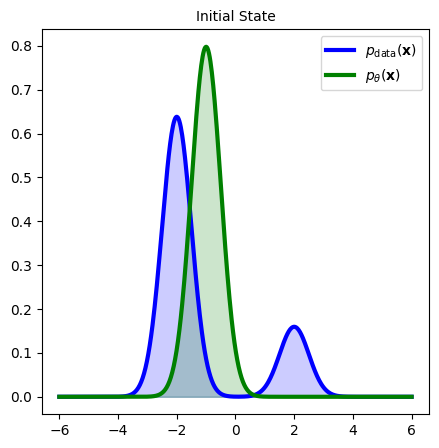

In [7]:
mu_start = -1.0
sigma_start = 0.5

# sigma must stay positive, so we optimize log sigma
mu = torch.tensor(mu_start, requires_grad=True, dtype=torch.double)
log_sigma = torch.tensor(np.log(sigma_start), requires_grad=True, dtype=torch.double)

def make_model_dist():
    return TD.Normal(mu, log_sigma.exp())

plot_distributions(x_grid, p_data.log_prob, make_model_dist().log_prob, title='Initial State')

In [8]:
def fit_gaussian(optimizer, loss_fn, data_log_prob, make_model_dist, n_iters):
    for it in range(n_iters):
        optimizer.zero_grad()
        
        model_dist = make_model_dist()
        
        loss = loss_fn(x_grid, data_log_prob, model_dist.log_prob)
        loss.backward()
        optimizer.step()

        if it % 10 == 0: 
            plot_distributions(x_grid, p_data.log_prob,
                               model_dist.log_prob, title=f'Step: {it}, Loss: {loss:.2f}')

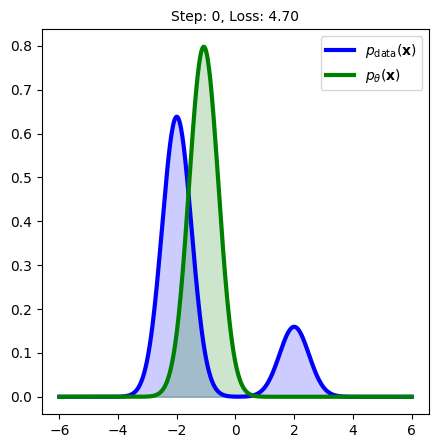

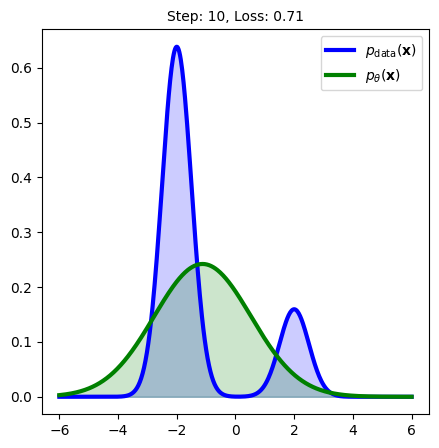

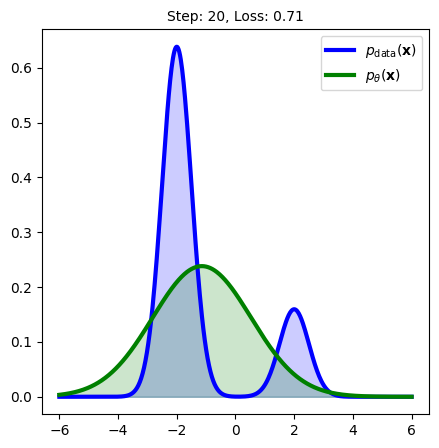

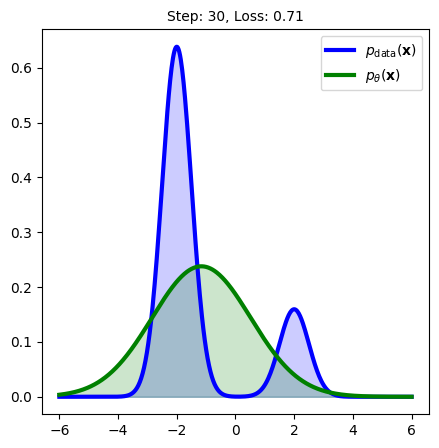

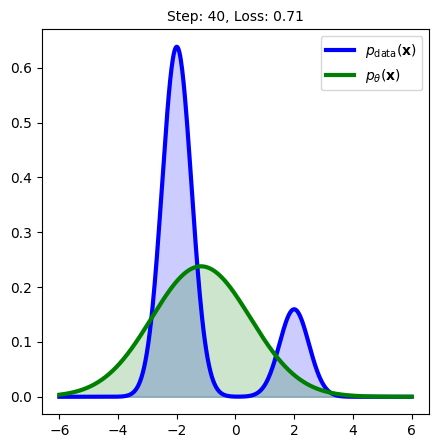

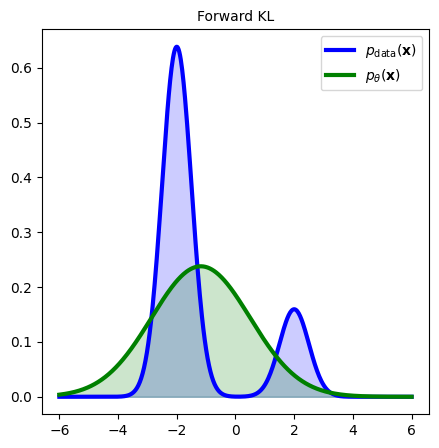

In [9]:
N_ITERS = 50
LEARNING_RATE = 0.1

mu = torch.tensor(mu_start, requires_grad=True, dtype=torch.double)
log_sigma = torch.tensor(np.log(sigma_start), requires_grad=True, dtype=torch.double)

optimizer = torch.optim.SGD([mu, log_sigma], lr=LEARNING_RATE)

fit_gaussian(optimizer, forward_KL_loss_fn, p_data.log_prob, make_model_dist, N_ITERS)

plot_distributions(
    x_grid, 
    p_data.log_prob, 
    make_model_dist().log_prob, 
    title='Forward KL', 
)

**Поведение**:

- Интеграл взвешен $p_{\text{data}}(\mathbf{x})$, поэтому важны только те области, где есть реальные данные

- Если $p_{\text{data}}(\mathbf{x}) > 0$, но $p_{\boldsymbol{\theta}}(\mathbf{x}) \to 0$, то $\log \frac{p_{\text{data}}(\mathbf{x})}{p_{\boldsymbol{\theta}}(\mathbf{x})}$ взрывается до $+\infty$

- Чтобы минимизировать этот лосс, модель вынуждена размещать вероятностную массу везде, где $p_{\text{data}}(\mathbf{x}) > 0$

- Это называется **покрытием мод** (**mode-covering**): модель «растягивается», чтобы покрыть обе моды, и образцы получаются размытыми (как у VAE)

#### Reverse KL

$$KL(p_{\boldsymbol{\theta}} \,||\, p_{\text{data}}) = \int p_{\boldsymbol{\theta}}(\mathbf{x}) \log \frac{p_{\boldsymbol{\theta}}(\mathbf{x})}{p_{\text{data}}(\mathbf{x})} d\mathbf{x}$$

In [10]:
# Reverse KL: KL(Model || Real)
reverse_KL_loss_fn = lambda x_grid, data_log_prob, model_log_prob: KLD(x_grid, model_log_prob, data_log_prob)

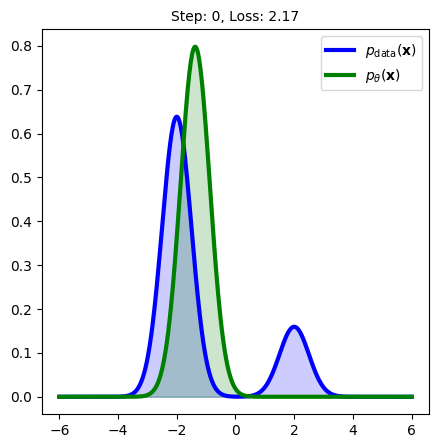

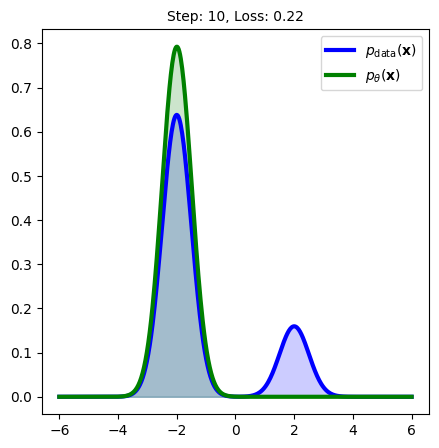

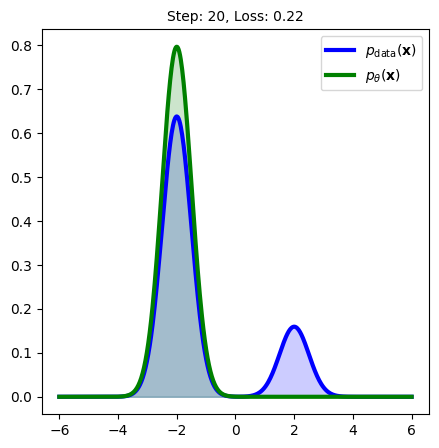

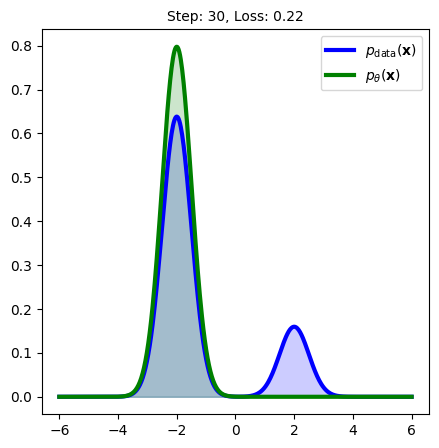

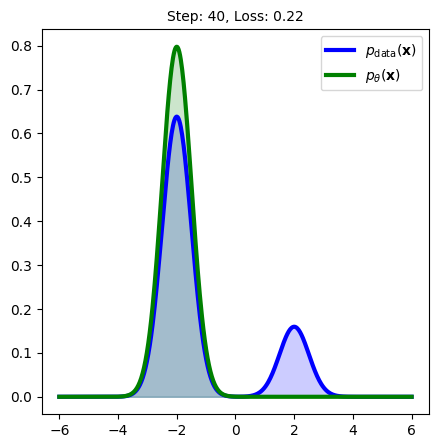

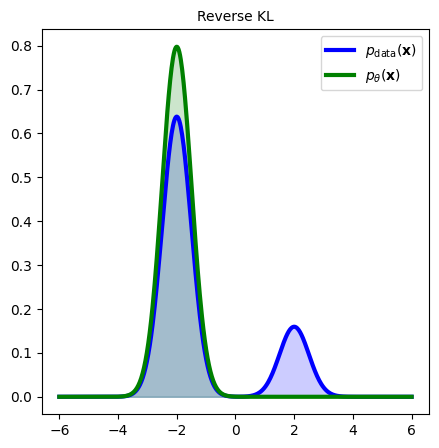

In [11]:
N_ITERS = 50
LEARNING_RATE = 0.1

mu = torch.tensor(mu_start, requires_grad=True, dtype=torch.double)
log_sigma = torch.tensor(np.log(sigma_start), requires_grad=True, dtype=torch.double)

optimizer = torch.optim.SGD([mu, log_sigma], lr=LEARNING_RATE)

fit_gaussian(optimizer, reverse_KL_loss_fn, p_data.log_prob, make_model_dist, N_ITERS)

plot_distributions(
    x_grid, 
    p_data.log_prob, 
    make_model_dist().log_prob, 
    title='Reverse KL',
)

**Поведение**:

- Интеграл взвешен $p_{\boldsymbol{\theta}}(\mathbf{x})$, поэтому важны только те области, куда модель кладёт вероятность

- Если $p_{\boldsymbol{\theta}}(\mathbf{x}) > 0$ (модель генерирует образец), но $p_{\text{data}}(\mathbf{x}) \to 0$ (образец «нереалистичен»), то $\log \frac{p_{\boldsymbol{\theta}}(\mathbf{x})}{p_{\text{data}}(\mathbf{x})}$ взрывается до $+\infty$

- А вот **за пропущенную моду штрафа нет**: там $p_{\boldsymbol{\theta}}(\mathbf{x}) \approx 0$, и её вклад в интеграл $\approx 0$

- Поэтому модели выгодно сесть на одну моду и точно её воспроизвести. Это называется **поиском мод** (**mode-seeking**)

### Jensen-Shannon Divergence

$$JSD(p_{\text{data}} \,||\, p_{\boldsymbol{\theta}}) = \frac{1}{2} KL\left(p_{\text{data}} \,\Big|\Big|\, m\right) + \frac{1}{2} KL\left(p_{\boldsymbol{\theta}} \,\Big|\Big|\, m\right), \qquad m(\mathbf{x}) = \frac{p_{\text{data}}(\mathbf{x}) + p_{\boldsymbol{\theta}}(\mathbf{x})}{2}$$

In [12]:
def JSD(x_grid, log_prob1, log_prob2):
    
    # log(M) = log( (exp(log_prob1) + exp(log_prob2)) / 2 )
    def log_prob_mean(x):
        prob_mean = (log_prob1(x).exp() + log_prob2(x).exp()) / 2
        return prob_mean.log()
    
    # JSD = 0.5 * KL(P1 || M) + 0.5 * KL(P2 || M)
    return (KLD(x_grid, log_prob1, log_prob_mean) + KLD(x_grid, log_prob2, log_prob_mean)) / 2

In [13]:
JSD_loss_fn = lambda x_grid, data_log_prob, model_log_prob: JSD(x_grid, data_log_prob, model_log_prob)

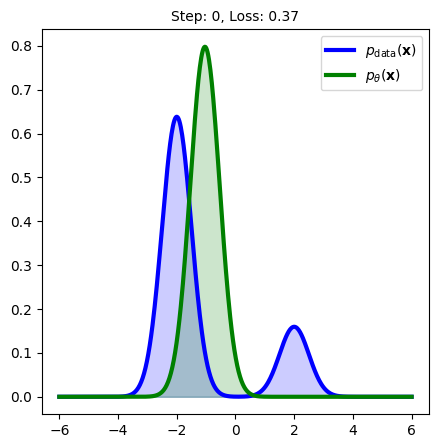

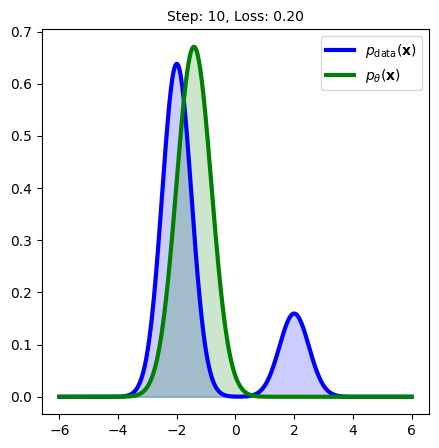

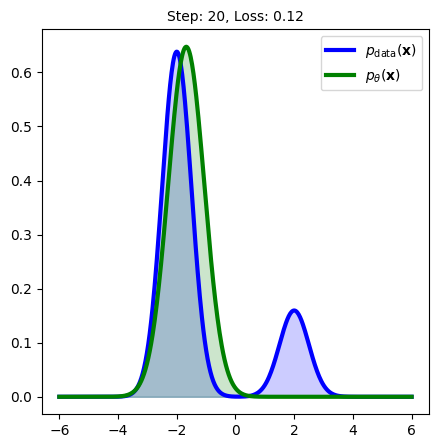

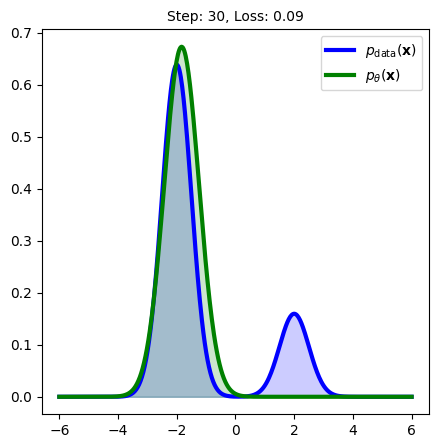

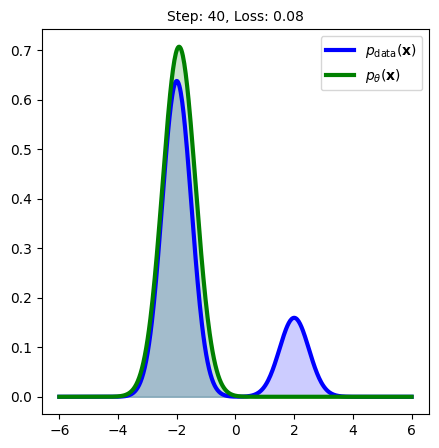

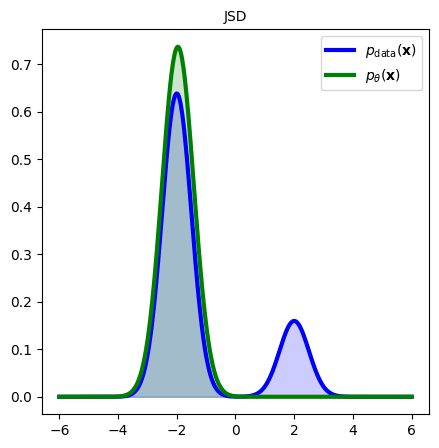

In [14]:
N_ITERS = 50
LEARNING_RATE = 0.1

mu = torch.tensor(mu_start, requires_grad=True, dtype=torch.double)
log_sigma = torch.tensor(np.log(sigma_start), requires_grad=True, dtype=torch.double)

optimizer = torch.optim.SGD([mu, log_sigma], lr=LEARNING_RATE)

fit_gaussian(optimizer, JSD_loss_fn, p_data.log_prob, make_model_dist, N_ITERS)

plot_distributions(
    x_grid, 
    p_data.log_prob, 
    make_model_dist().log_prob, 
    title='JSD', 
)

**Поведение**:

- JSD симметрична и ограничена: $m \geq p_{\text{data}}/2$, поэтому $p_{\text{data}}/m \leq 2$ (и аналогично $p_{\boldsymbol{\theta}}/m \leq 2$), откуда $JSD \leq \log 2$

- Значит, в отличие от Forward KL, за пропущенную моду штраф **конечен**, и сесть на одну моду оказывается дешевле, чем растянуться на обе. Поэтому на практике JSD ведёт себя близко к **Reverse KL** (mode-seeking).

### Generative Adversarial Networks

Генеративно-состязательные сети (GAN) — это генеративные модели, идея которых заключается в состязательном обучении двух нейросетей:

1. **`Generator`**:

**Задача**: создавать поддельные данные, которые невозможно отличить от настоящих

**Вход**: случайный вектор $\mathbf{z}$ из латентного пространства

**Выход**: сгенерированное изображение $\hat{\mathbf{x}}$.

**Цель**: обмануть дискриминатор

2. **`Discriminator`**:

**Задача**: Определить, является ли изображение настоящим или сгенерированным

**Вход**: настоящее $\mathbf{x}$ или поддельное $\hat{\mathbf{x}}$ изображение

**Выход**: вероятность того, что изображение настоящее, $D(\mathbf{x}) = p(y=1 \mid \mathbf{x})$

**Цель**: стать как можно лучше в распознавании изображений

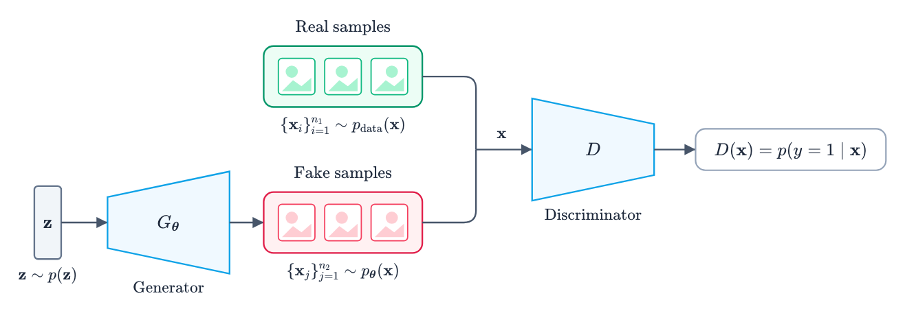

### Функция потерь

Обучение GAN — это поиск равновесия с помощью функции потерь $V(D, G)$:

$$\min_G \max_D V(D, G) = \mathbb{E}_{\mathbf{x} \sim p_{\text{data}}}[\log D(\mathbf{x})] + \mathbb{E}_{\mathbf{z} \sim p(\mathbf{z})}[\log(1 - D(G(\mathbf{z})))]$$

**`Обучение дискриминатора:`**

Дискриминатор $D$ хочет максимизировать функцию $\max_D V(D, G)$

  - $\mathbb{E}_{\mathbf{x} \sim p_{\text{data}}}[\log D(\mathbf{x})]$: для настоящих изображений $\mathbf{x}$, $D$ хочет, чтобы $D(\mathbf{x})$ было близко к 1 ($\log(1) = 0$)

  - $\mathbb{E}_{\mathbf{z} \sim p(\mathbf{z})}[\log(1 - D(G(\mathbf{z})))]$: для поддельных изображений $G(\mathbf{z})$, $D$ хочет, чтобы $D(G(z))$ было близко к 0 (т.е. $\log(1 - 0) = 0$).

**`Обучение генератора:`**

Генератор $G$ хочет минимизировать функцию $\max_D V(D, G)$ и может влиять только на второй член:

 - $\mathbb{E}_{\mathbf{z} \sim p(\mathbf{z})}[\log(1 - D(G(\mathbf{z})))]$:
 
 - $G$ хочет, чтобы $D(G(\mathbf{z}))$ было близко к 1 (чтобы $D$ ошибся). Если $D(G(\mathbf{z})) \to 1$, то $1 - D(G(\mathbf{z})) \to 0$, и $\log(0) \to -\infty$.

#### Цель генератора

Зафиксируем Генератор и найдём лучшего Дискриминатора:

$$D^*(\mathbf{x}) = \frac{p_{\text{data}}(\mathbf{x})}{p_{\text{data}}(\mathbf{x}) + p_{\boldsymbol{\theta}}(\mathbf{x})}$$

- Это доля реальных объектов среди всех, что встречаются рядом с $\mathbf{x}$
- Если $p_{\text{data}}(\mathbf{x}) = p_{\boldsymbol{\theta}}(\mathbf{x})$, то $D^*(\mathbf{x}) = \frac{1}{2}$: дискриминатор не может отличить фейки

Подставим $D^*$ в функцию потерь:

$$V(D^*, G) = 2 \cdot JSD(p_{\text{data}} \,||\, p_{\boldsymbol{\theta}}) - 2\log 2$$

- Значит, обучение Генератора минимизирует JSD
- Минимум равен $-2\log 2$ и достигается при $p_{\boldsymbol{\theta}} = p_{\text{data}}$

#### Проблема насыщения

**Исходный лосс Генератора**

- Пока Дискриминатор уверенно отличает фейки, $D(G(\mathbf{z})) \approx 0$, и причина проблемы в **сигмоиде** на выходе $D$
- Пусть $D = \sigma(a)$, где $a$ — логит
- Производная сигмоиды равна $D(1 - D)$. При $a = 0$ производная равна $0.25$, а при $a = -5$ всего около $0.007$
- Если Дискриминатор уверен, что это фейк, то $a$ сильно отрицательное и $D \approx 0$, то есть мы на левом краю

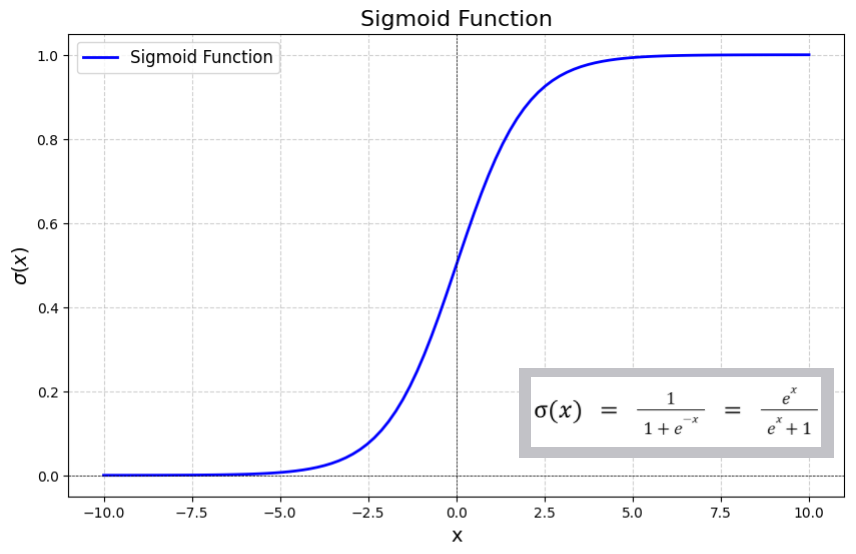

- Градиент лосса по $a$ — это произведение двух множителей, и именно производная сигмоиды обнуляет его

$$\frac{\partial}{\partial a} \log(1 - \sigma(a)) = \underbrace{-\frac{1}{1 - D}}_{\approx -1} \cdot \underbrace{D(1 - D)}_{\approx 0} = -D \approx 0 \quad \text{при } D \approx 0$$

- В начале обучения Генератор как раз слабый, поэтому учиться ему нечем

**Non-saturating loss**

- Поэтому на практике Генератор минимизирует другой лосс

$$L_G = -\mathbb{E}_{\mathbf{z} \sim p(\mathbf{z})}[\log D(G(\mathbf{z}))]$$

- Множитель $D$ в производной сигмоиды сокращается:

$$\frac{\partial}{\partial a} \log \sigma(a) = \frac{1}{D} \cdot D(1 - D) = 1 - D \approx 1 \quad \text{при } D \approx 0$$

- Оба лосса уменьшаются, когда $D(G(\mathbf{z}))$ растёт к 1, поэтому Генератор по-прежнему старается обмануть Дискриминатора
- Градиенты при $D(G(\mathbf{z})) \approx 0$ теперь большие
- В коде это **Binary Cross-Entropy**, где $p$ — вероятность, а $y$ — таргет

$$\text{BCE}(p, y) = -\left[y \log p + (1 - y) \log(1 - p)\right]$$

- Она равна $-\log p$ при таргете $y = 1$ и $-\log(1 - p)$ при таргете $y = 0$
- Чтобы не писать $L_G$ отдельно, Генератору подставляют обманные метки. Таргет для фейков равен 1, как будто они настоящие, и получается ровно $L_G$

$$\text{BCE}\big(D(G(\mathbf{z})), \, 1\big) = -\log D(G(\mathbf{z})) = L_G$$

- У Дискриминатора та же BCE, но таргет для фейков равен 0

$$\text{BCE}\big(D(G(\mathbf{z})), \, 0\big) = -\log\big(1 - D(G(\mathbf{z}))\big)$$

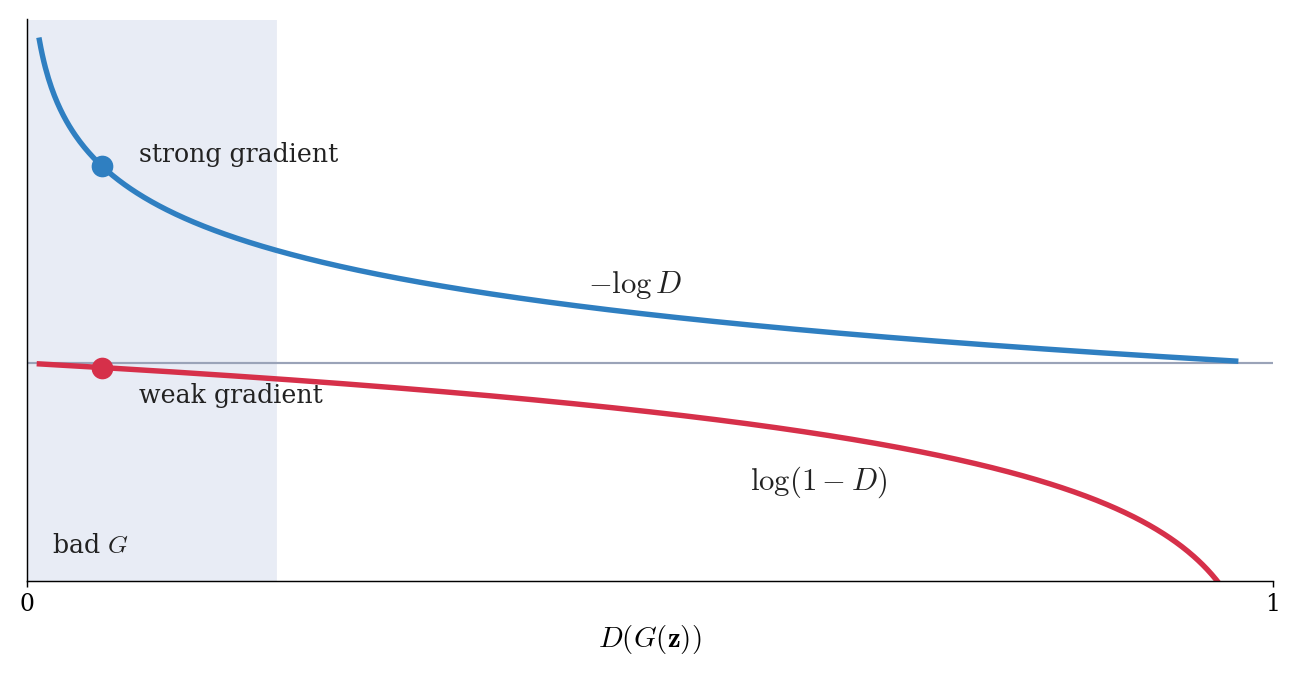

- Авторы GAN пишут, что новый лосс даёт ту же точку равновесия, но без доказательства (раздел 3 [статьи](https://arxiv.org/abs/1406.2661))
- В [Arjovsky, Bottou, 2017](https://arxiv.org/abs/1701.04862) (Theorem 2.5) показано, что при оптимальном Дискриминаторе $D^*$, посчитанном для текущих параметров $\boldsymbol{\theta}_0$, градиент нового лосса совпадает с градиентом такого выражения

$$\nabla_{\boldsymbol{\theta}}\left[KL(p_{\boldsymbol{\theta}} \,\|\, p_{\text{data}}) - 2 \cdot JSD(p_{\text{data}} \,\|\, p_{\boldsymbol{\theta}})\right]$$

- Значит, шаги по новому лоссу уменьшают выражение, минимум которого там же, где у исходного лосса

Но это не чистая минимизация JSD, как у исходного лосса!

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
latent_dim = 1   
batch_size = 32  

mix_probs = torch.tensor([0.7, 0.3], device=device)
mix_means = torch.tensor([-3., 3.], device=device)
mix_scales = torch.tensor([1., 1.], device=device)
p_data = TD.MixtureSameFamily(
    TD.Categorical(mix_probs), 
    TD.Normal(mix_means, mix_scales)
)

def sample_data(batch_size):
    return p_data.sample((batch_size, 1)).to(device)

def data_pdf(x):
    return p_data.log_prob(torch.tensor(x, device=device)).exp().cpu().numpy()

def sample_z(batch_size):
    return torch.rand(batch_size, latent_dim, device=device) - 0.5

#### Архитектура

Обе сети — обычные MLP из линейных слоёв с ReLU.

- **Генератор**: $\mathbf{z} \to \hat{\mathbf{x}}$, на выходе нет активации
- **Дискриминатор**: $\mathbf{x} \to D(\mathbf{x})$, на выходе сигмоида — она превращает число в вероятность

In [18]:
class Generator(nn.Module):
    def __init__(self, hiddens):
        super().__init__()
        
        layers = []
        for i, (in_dim, out_dim) in enumerate(zip(hiddens[:-1], hiddens[1:])):
            layers.append(nn.Linear(in_dim, out_dim))
            if i < len(hiddens) - 2:
                layers.append(nn.ReLU())
        
        self.model = nn.Sequential(*layers)

    def forward(self, z):
        return self.model(z)
    
class Discriminator(nn.Module):
    def __init__(self, hiddens, sigmoid=True):
        super().__init__()
        
        layers = []
        for i, (in_dim, out_dim) in enumerate(zip(hiddens[:-1], hiddens[1:])):
            layers.append(nn.Linear(in_dim, out_dim))
            if i < len(hiddens) - 2:
                layers.append(nn.ReLU())
        
        # The discriminator outputs a probability D(x), so the last layer is a sigmoid
        if sigmoid:
            layers.append(nn.Sigmoid())
                
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

#### Шаг обучения

**Шаг Дискриминатора:**

- на реальных данных считаем BCE с таргетом $1$
- на фейках считаем BCE с таргетом $0$
- берём среднее двух лоссов
- фейки считаем под `torch.no_grad()`, чтобы градиенты не шли в $G$

**Шаг Генератора:**

- пропускаем фейки через $D$
- считаем BCE с таргетом $1$: генератор хочет, чтобы $D$ назвал фейки настоящими
- это тот самый non-saturating loss $-\log D(G(\mathbf{z}))$ из блока выше

In [27]:
class VanillaGAN:
    def __init__(self, G, D, sample_z, sample_data, device, lr_D, lr_G, batch_size):
        self.G = G.to(device)
        self.D = D.to(device)
        self.sample_z = sample_z
        self.sample_data = sample_data
        self.device = device
        self.batch_size = batch_size
        
        self.criterion = nn.BCELoss()
        
        self.optim_D = optim.Adam(D.parameters(), lr=lr_D, betas=(0.5, 0.999))
        self.optim_G = optim.Adam(G.parameters(), lr=lr_G, betas=(0.5, 0.999))

    def generate_samples(self, z=None, num=None) -> torch.Tensor:
        
        num = self.batch_size if num is None else num
        z = self.sample_z(num) if z is None else z
        
        with torch.no_grad():
            samples = self.G(z)
        return samples

    def train_step_D(self) -> tuple[float, float]:
        self.D.zero_grad()

        real_samples = self.sample_data(self.batch_size)
        current_batch_size = real_samples.size(0)
        real_targets = torch.ones(current_batch_size, 1, device=self.device)
        
        pred_real = self.D(real_samples)
        loss_real = self.criterion(pred_real, real_targets)

        z = self.sample_z(current_batch_size)
        with torch.no_grad():
            fake_samples = self.G(z)
        
        fake_targets = torch.zeros(current_batch_size, 1, device=self.device)
        
        pred_fake = self.D(fake_samples)
        loss_fake = self.criterion(pred_fake, fake_targets)

        loss = (loss_real + loss_fake) / 2
        loss.backward()
        self.optim_D.step()
        
        return loss_real.item(), loss_fake.item()

    def train_step_G(self) -> float:
        self.G.zero_grad()
        
        z = self.sample_z(self.batch_size)
        # G wants D to label its fakes as real, so the target is 1
        real_targets = torch.ones(self.batch_size, 1, device=self.device)
        
        fake_samples = self.G(z)
        pred_fake = self.D(fake_samples)
        
        loss = self.criterion(pred_fake, real_targets)
        loss.backward()
        self.optim_G.step()
        
        return loss.item()

In [28]:
def visualize_GAN(z_samples, real_samples, fake_samples=None, 
                  model=None, real_pdf=None, title="", 
                  is_critic=False):
    plt.figure(figsize=(8, 5))
    plt.title(title)
    
    bins = np.linspace(-7, 7, 100)
    x_axis = np.linspace(-7, 7, 200)

    plt.hist(z_samples.flatten(), label='Noise (z)', alpha=0.5, density=True, bins=bins, color='blue')
    plt.hist(real_samples.flatten(), label='Real Data (x)', alpha=0.5, density=True, bins=bins, color='green')
    if fake_samples is not None:
        plt.hist(fake_samples.flatten(), label='Fake Data (G(z))', alpha=0.5, density=True, bins=bins, color='red')
    
    if real_pdf is not None:
        plt.plot(x_axis, real_pdf(x_axis), 'g-', label='Real PDF')
    
    if model is not None:
        with torch.no_grad():
            model_device = next(model.parameters()).device
            x_tensor = torch.from_numpy(x_axis).float().unsqueeze(-1).to(model_device)
            out = model(x_tensor)
            
            if is_critic:
                output_scores = out.cpu().numpy()
                plt.plot(x_axis, output_scores, 'b--', label='Critic Scores f(x)')   
            else:
                output_probs = out.cpu().numpy()
                
                plt.plot(x_axis, output_probs, 'b--', label='Discriminator D(x)')
                plt.ylim(0, 1.0)
                
    plt.legend(loc='upper left')
    plt.show()

In [29]:
gen_hiddens = [latent_dim, 64, 64, 64, 1]
dis_hiddens = [1, 64, 64, 64, 1]

G = Generator(gen_hiddens).to(device)
D = Discriminator(dis_hiddens).to(device)

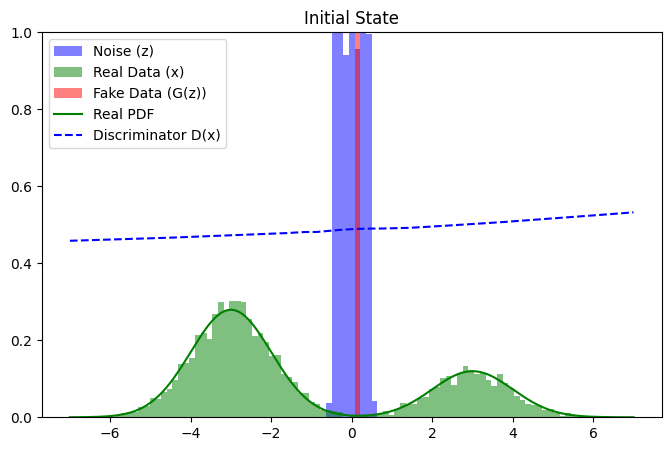

In [30]:
visualize_GAN(
    sample_z(5000).cpu().numpy(),
    sample_data(5000).cpu().numpy(),
    G(sample_z(5000)).detach().cpu().numpy(),
    D,
    data_pdf,
    title="Initial State"
    )

In [31]:
# The discriminator is trained harder: larger lr and k_steps_D steps per generator step (see the loop below).
# A strong D does not kill the generator's gradients only because we use the non-saturating loss.
lr_D = 1e-3           
lr_G = 2e-4                  
epochs = 50           
batches_per_epoch = 100

vanilla_gan = VanillaGAN(G, D, sample_z, sample_data, device, lr_D, lr_G, batch_size)

Epoch 1/50: G_loss=3.755, D_real=0.082, D_fake=0.070


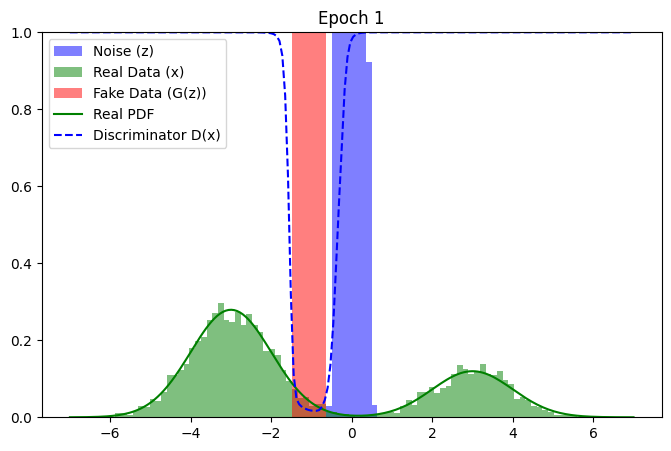

Epoch 2/50: G_loss=2.309, D_real=0.291, D_fake=0.153
Epoch 3/50: G_loss=1.203, D_real=0.534, D_fake=0.396
Epoch 4/50: G_loss=1.023, D_real=0.587, D_fake=0.477
Epoch 5/50: G_loss=1.008, D_real=0.589, D_fake=0.492


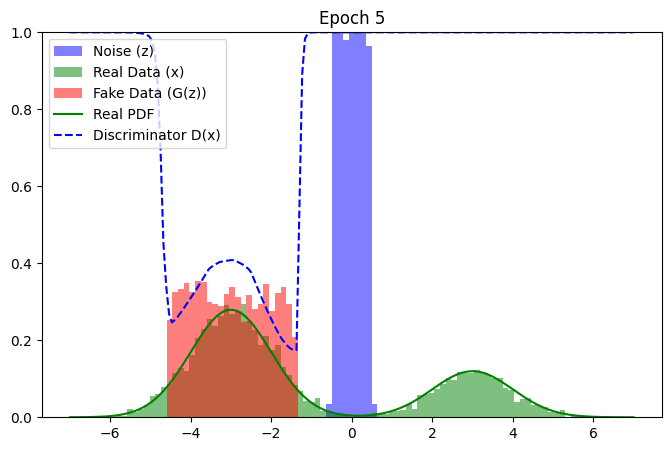

Epoch 6/50: G_loss=0.999, D_real=0.590, D_fake=0.485
Epoch 7/50: G_loss=0.997, D_real=0.590, D_fake=0.488
Epoch 8/50: G_loss=1.001, D_real=0.591, D_fake=0.489
Epoch 9/50: G_loss=0.981, D_real=0.593, D_fake=0.494
Epoch 10/50: G_loss=0.990, D_real=0.593, D_fake=0.491


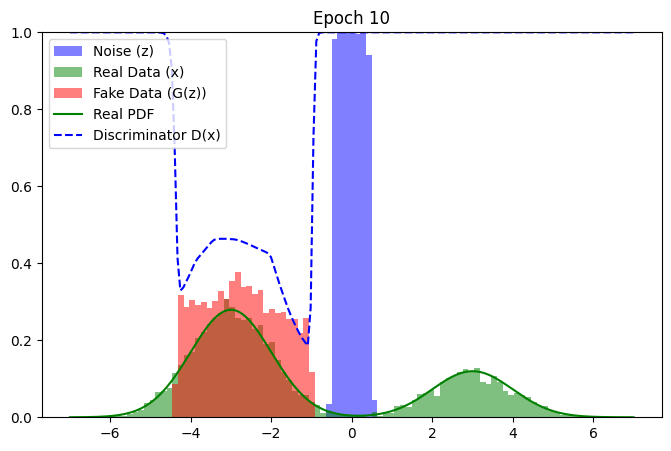

Epoch 11/50: G_loss=0.985, D_real=0.593, D_fake=0.494
Epoch 12/50: G_loss=0.960, D_real=0.597, D_fake=0.495
Epoch 13/50: G_loss=0.969, D_real=0.596, D_fake=0.494
Epoch 14/50: G_loss=0.975, D_real=0.597, D_fake=0.495
Epoch 15/50: G_loss=0.976, D_real=0.595, D_fake=0.497


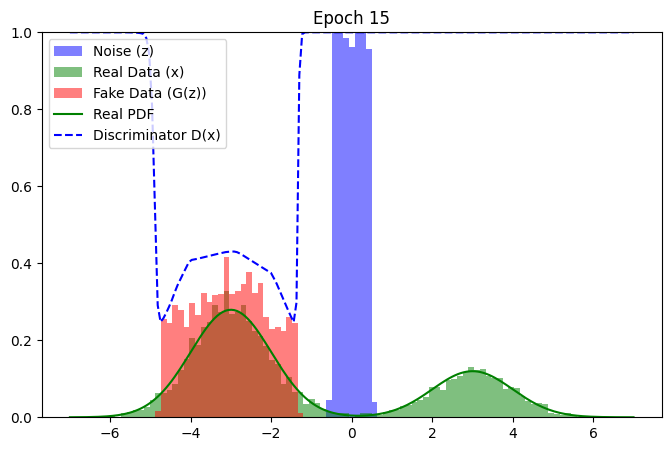

Epoch 16/50: G_loss=0.963, D_real=0.597, D_fake=0.497
Epoch 17/50: G_loss=0.963, D_real=0.598, D_fake=0.499
Epoch 18/50: G_loss=0.968, D_real=0.594, D_fake=0.490
Epoch 19/50: G_loss=0.959, D_real=0.599, D_fake=0.497
Epoch 20/50: G_loss=0.961, D_real=0.597, D_fake=0.498


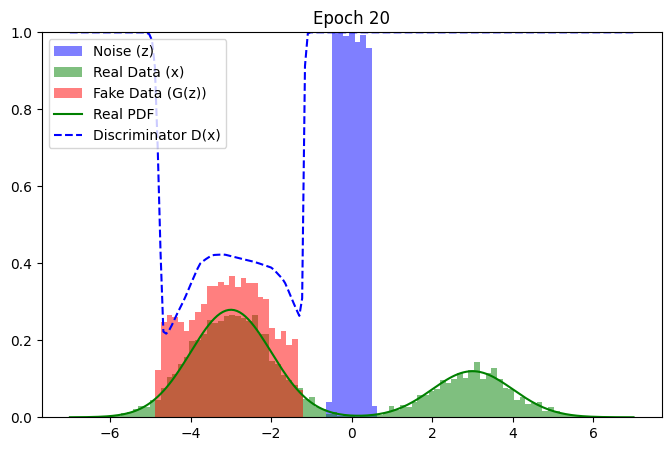

Epoch 21/50: G_loss=0.956, D_real=0.599, D_fake=0.497
Epoch 22/50: G_loss=0.964, D_real=0.598, D_fake=0.494
Epoch 23/50: G_loss=0.953, D_real=0.598, D_fake=0.495
Epoch 24/50: G_loss=0.958, D_real=0.599, D_fake=0.495
Epoch 25/50: G_loss=0.956, D_real=0.599, D_fake=0.497


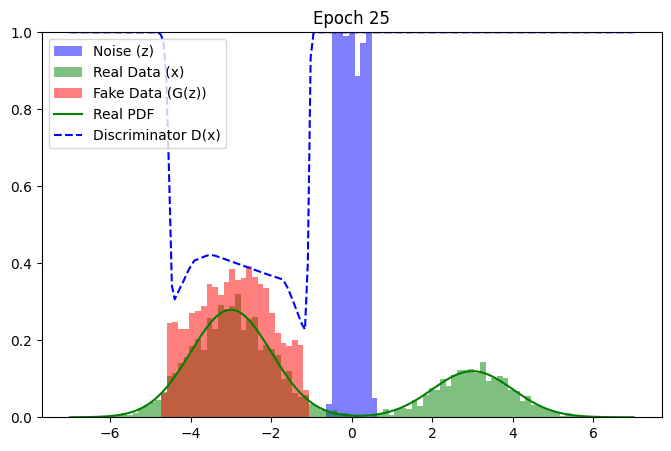

Epoch 26/50: G_loss=0.946, D_real=0.603, D_fake=0.505
Epoch 27/50: G_loss=0.947, D_real=0.602, D_fake=0.504
Epoch 28/50: G_loss=0.948, D_real=0.603, D_fake=0.505
Epoch 29/50: G_loss=0.945, D_real=0.601, D_fake=0.505
Epoch 30/50: G_loss=0.952, D_real=0.600, D_fake=0.497


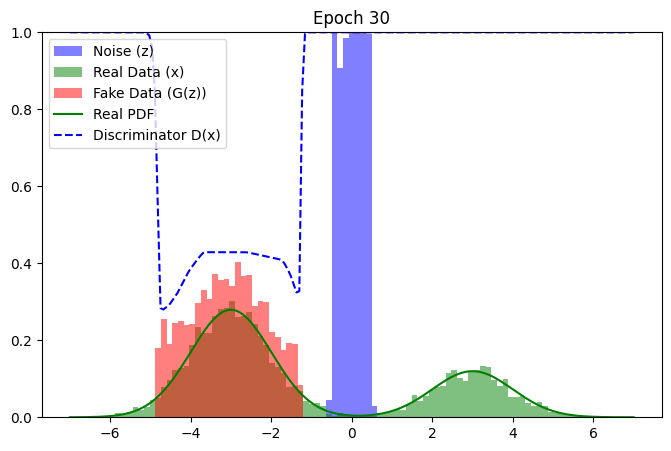

Epoch 31/50: G_loss=0.946, D_real=0.601, D_fake=0.501
Epoch 32/50: G_loss=0.947, D_real=0.598, D_fake=0.499
Epoch 33/50: G_loss=0.951, D_real=0.602, D_fake=0.494
Epoch 34/50: G_loss=0.949, D_real=0.605, D_fake=0.501
Epoch 35/50: G_loss=0.939, D_real=0.605, D_fake=0.506


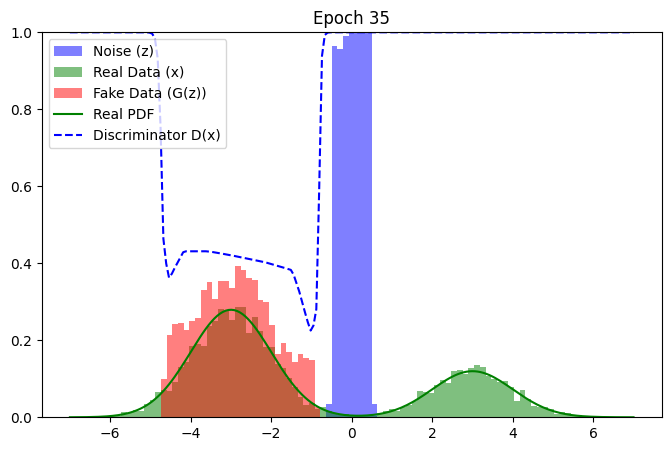

Epoch 36/50: G_loss=0.947, D_real=0.600, D_fake=0.501
Epoch 37/50: G_loss=0.936, D_real=0.604, D_fake=0.505
Epoch 38/50: G_loss=0.934, D_real=0.609, D_fake=0.512
Epoch 39/50: G_loss=0.947, D_real=0.603, D_fake=0.501
Epoch 40/50: G_loss=0.951, D_real=0.604, D_fake=0.503


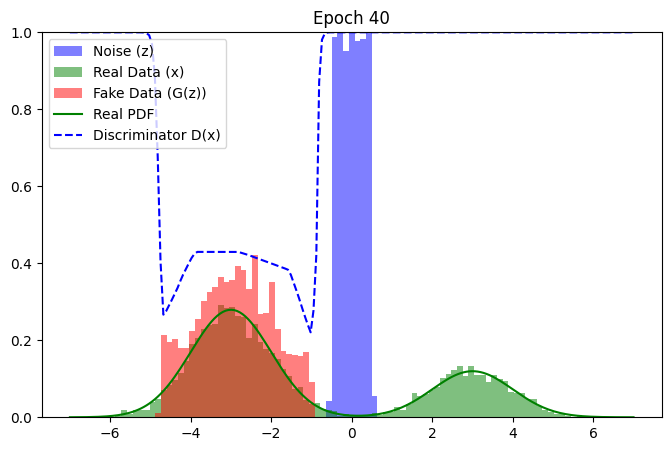

Epoch 41/50: G_loss=0.939, D_real=0.606, D_fake=0.508
Epoch 42/50: G_loss=0.934, D_real=0.605, D_fake=0.506
Epoch 43/50: G_loss=0.940, D_real=0.606, D_fake=0.511
Epoch 44/50: G_loss=0.936, D_real=0.604, D_fake=0.505
Epoch 45/50: G_loss=0.929, D_real=0.609, D_fake=0.517


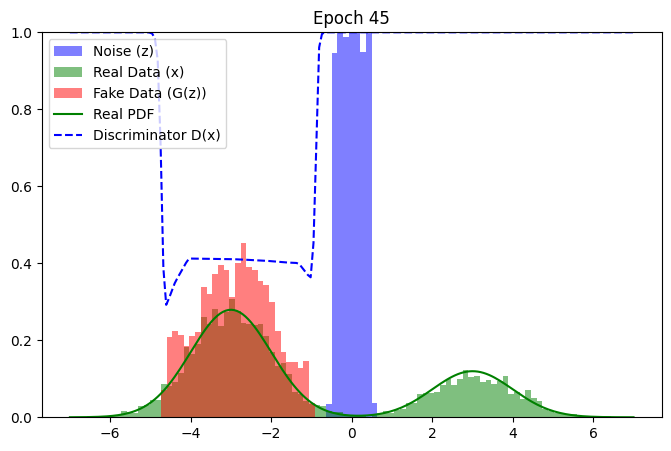

Epoch 46/50: G_loss=0.942, D_real=0.607, D_fake=0.504
Epoch 47/50: G_loss=0.927, D_real=0.606, D_fake=0.512
Epoch 48/50: G_loss=0.930, D_real=0.610, D_fake=0.509
Epoch 49/50: G_loss=0.934, D_real=0.607, D_fake=0.506
Epoch 50/50: G_loss=0.930, D_real=0.608, D_fake=0.511


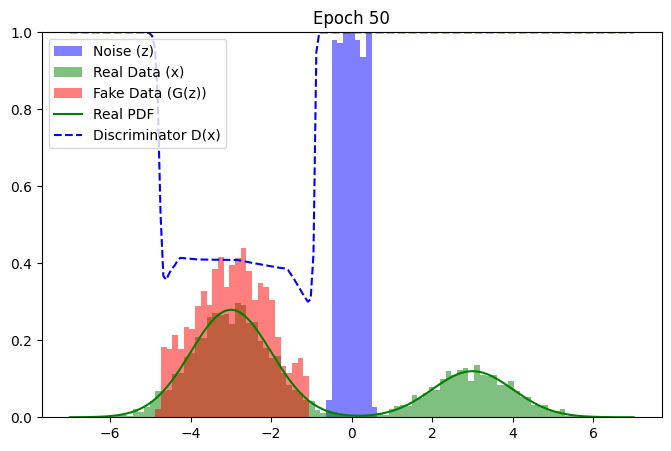

In [151]:
k_steps_D = 5

for epoch in range(epochs):
    
    loss_g_running = 0.0
    loss_d_real_running = 0.0
    loss_d_fake_running = 0.0
    
    for i in range(batches_per_epoch):
        
        # Train the Discriminator k_steps_D times
        for _ in range(k_steps_D):
            loss_d_real_step, loss_d_fake_step = vanilla_gan.train_step_D() 
            loss_d_real_running += loss_d_real_step
            loss_d_fake_running += loss_d_fake_step

        # Train the Generator 1 time
        loss_g_step = vanilla_gan.train_step_G()
        loss_g_running += loss_g_step
    
    avg_g_loss = loss_g_running / batches_per_epoch
    avg_d_real_loss = loss_d_real_running / (batches_per_epoch * k_steps_D)
    avg_d_fake_loss = loss_d_fake_running / (batches_per_epoch * k_steps_D)
    
    print(f"Epoch {epoch+1}/{epochs}: "
          f"G_loss={avg_g_loss:.3f}, D_real={avg_d_real_loss:.3f}, D_fake={avg_d_fake_loss:.3f}")

    if epoch == 0 or (epoch+1) % 5 == 0:
        visualize_GAN(
            sample_z(5000).cpu().numpy(),
            sample_data(5000).cpu().numpy(),
            vanilla_gan.generate_samples(num=5000).cpu().numpy(),
            vanilla_gan.D,
            data_pdf,
            title=f"Epoch {epoch+1}"
        )

Обратите внимание на синюю пунктирную линию $D(x)$. Там, где распределение фейков совпало с реальным, дискриминатор выдаёт значения около $\frac{1}{2}$ — ровно как предсказывает $D^* = \frac{p_{\text{data}}}{p_{\text{data}} + p_{\boldsymbol{\theta}}}$.

<div style="background-color:#fff8e1; border-left:4px solid #f5a623; padding:10px 15px; border-radius:4px; margin:10px 0;">

**Вопрос для размышления:** какие проблемы видите на этом графике?

</div>

<div style="background-color:#fff8e1; border-left:4px solid #f5a623; padding:10px 15px; border-radius:4px; margin:10px 0;">

**Вопрос для размышления:** что можно с этим сделать?

</div>

### Wasserstein GAN

У GAN с обычным лоссом есть проблема:

- Реальные данные лежат на низкоразмерном многообразии, поэтому носители $p_{\text{data}}$ и $p_{\boldsymbol{\theta}}$ почти всегда не пересекаются
- Тогда JSD постоянна, и градиенты для $G$ исчезают
- Расстояние Вассерштейна в этом случае подходит лучше

В модели `WGAN` предложили использовать именно его — **расстояние Вассерштейна** $W(p_{\text{data}}, p_{\boldsymbol{\theta}})$.

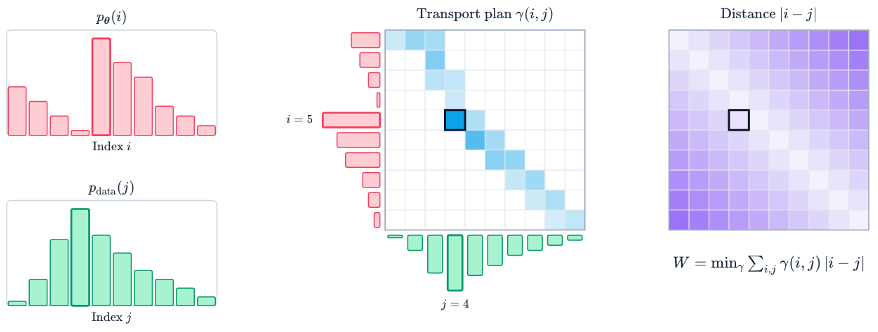

В непрерывном случае расстояние Вассерштейна определяется следующим образом:

$$W(p_{\text{data}}, p_{\boldsymbol{\theta}}) = \inf_{\gamma \in \Gamma(p_{\text{data}}, p_{\boldsymbol{\theta}})} \mathbb{E}_{(\mathbf{x}, \mathbf{y}) \sim \gamma} [\|\mathbf{x} - \mathbf{y}\|]$$

Однако вычислить $W$ напрямую (найти самый эффективный транспортный план) — невозможно.

Поэтому мы используем **двойственность Канторовича-Рубинштейна**. Вместо поиска $\inf$, теорема предлагает искать $\max$ по всем $K$-Липшицевым функциям $f$:

$$W(p_{\text{data}}, p_{\boldsymbol{\theta}}) = \frac{1}{K} \max_{\|f\|_L \le K} \left( \mathbb{E}_{x \sim p_{\text{data}}}[f(x)] - \mathbb{E}_{x \sim p_{\boldsymbol{\theta}}}[f(x)] \right)$$

$K$-Липшицева функция — это функция, для которой

$$|f(x_1) - f(x_2)| \le K \|x_1 - x_2\|$$

Для дифференцируемой функции это то же самое, что $\|\nabla f(x)\| \le K$ везде.

Мы заменяем **Дискриминатор** на **Критика** (**Critic**), $f_\phi$.

Критик $f_\phi$ теперь выдает не вероятность, а любое вещественное число — **оценку** (**score**).

**Как ограничить скорость изменения нашей нейросети $f_\phi$?**

После каждого шага градиентного спуска Критика мы принудительно обрезаем все его веса, заставляя их находиться в небольшом диапазоне $[-c, c]$. Это называется **обрезкой весов** (**Weight Clipping**).

- Веса ограничены, поэтому и функция $f_\phi$ не может меняться слишком быстро
- В итоге получается $K$-Липшицева функция, где $K$ зависит от $c$ и архитектуры

In [33]:
class Critic(Discriminator):
    # Same network, but without the sigmoid: the output is a score f(x), not a probability
    def __init__(self, hiddens):
        super().__init__(hiddens, sigmoid=False)

In [34]:
class WGAN:
    def __init__(self, G, C, sample_z, sample_data, device, n_critic, clip_c, lr, batch_size):
        self.G = G.to(device)
        self.C = C.to(device)
        self.sample_z = sample_z
        self.sample_data = sample_data
        self.device = device
        self.batch_size = batch_size
        self.n_critic = n_critic
        self.clip_c = clip_c
        
        self.optim_C = optim.Adam(C.parameters(), lr=lr, betas=(0.5, 0.9))
        self.optim_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.9))

    def generate_samples(self, z=None, num=None) -> torch.Tensor:
        num = self.batch_size if num is None else num
        z = self.sample_z(num) if z is None else z
        with torch.no_grad():
            samples = self.G(z)
        return samples

    def train_step_C(self) -> tuple[float, float]:
        self.C.zero_grad()

        # Real Data
        real_samples = self.sample_data(self.batch_size)
        real_scores = self.C(real_samples)

        # Fake Data
        z = self.sample_z(self.batch_size)
        with torch.no_grad():
            fake_samples = self.G(z)
        fake_scores = self.C(fake_samples)

        # The critic maximizes E[f(x)] - E[f(G(z))], so we minimize the opposite
        loss_C = (fake_scores.mean()) - (real_scores.mean())
        
        loss_C.backward()
        self.optim_C.step()

        # Weight Clipping
        for p in self.C.parameters():
            p.data.clamp_(-self.clip_c, self.clip_c)
        
        return real_scores.mean().item(), fake_scores.mean().item()

    def train_step_G(self) -> float:
        self.G.zero_grad()
        
        z = self.sample_z(self.batch_size)
        fake_samples = self.G(z)
        fake_scores = self.C(fake_samples)

        # Loss: min [-E[f(G(z))]]
        loss_G = -fake_scores.mean()
        
        loss_G.backward()
        self.optim_G.step()
        
        return loss_G.item()

In [35]:
gen_hiddens = [latent_dim, 64, 64, 64, 1]
critic_hiddens = [1, 64, 64, 64, 1]

G = Generator(gen_hiddens).to(device)
C = Critic(critic_hiddens).to(device)

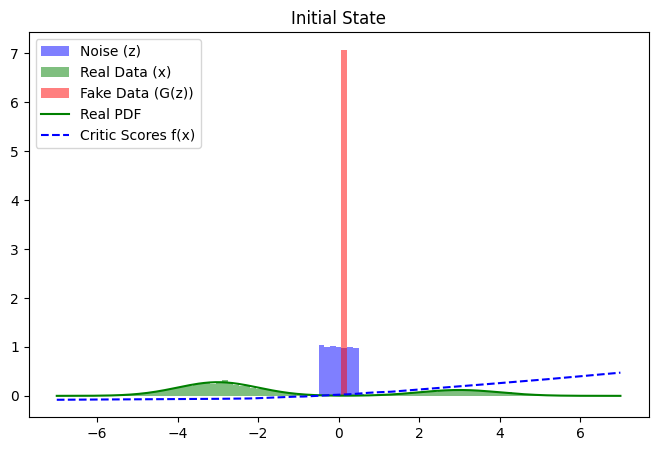

In [155]:
visualize_GAN(
    sample_z(5000).cpu().numpy(),
    sample_data(5000).cpu().numpy(),
    G(sample_z(5000)).detach().cpu().numpy(),
    C,
    data_pdf,
    title="Initial State",
    is_critic=True
)

In [156]:
lr = 1e-4
batch_size = 32
latent_dim = 1
n_critic = 5
clip_c = 0.1         
epochs = 50
batches_per_epoch = 100

wgan = WGAN(G, C, sample_z, sample_data, device, n_critic, clip_c, lr, batch_size)

Epoch 1/50: G=0.067, f_real=0.396, f_fake=-0.066, W_Dist=0.461
Epoch 2/50: G=0.123, f_real=2.248, f_fake=-0.120, W_Dist=2.367
Epoch 3/50: G=-0.730, f_real=4.628, f_fake=0.732, W_Dist=3.896
Epoch 4/50: G=-1.788, f_real=4.971, f_fake=1.807, W_Dist=3.164
Epoch 5/50: G=0.658, f_real=3.559, f_fake=-0.649, W_Dist=4.208


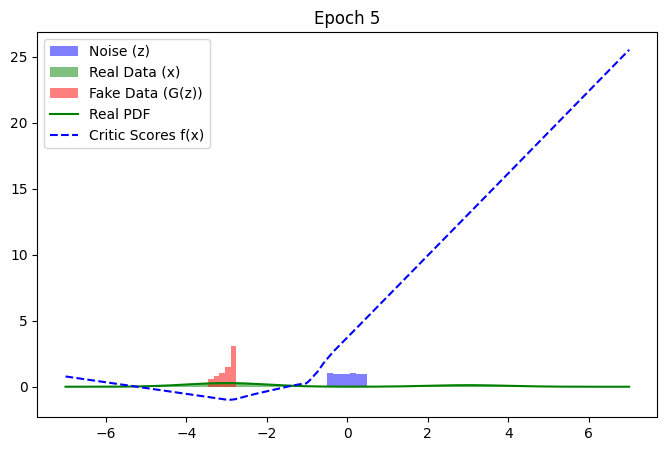

Epoch 6/50: G=1.008, f_real=3.651, f_fake=-1.008, W_Dist=4.659
Epoch 7/50: G=1.097, f_real=3.685, f_fake=-1.097, W_Dist=4.782
Epoch 8/50: G=1.159, f_real=3.972, f_fake=-1.153, W_Dist=5.125
Epoch 9/50: G=1.144, f_real=3.910, f_fake=-1.146, W_Dist=5.056
Epoch 10/50: G=0.944, f_real=3.996, f_fake=-0.950, W_Dist=4.946


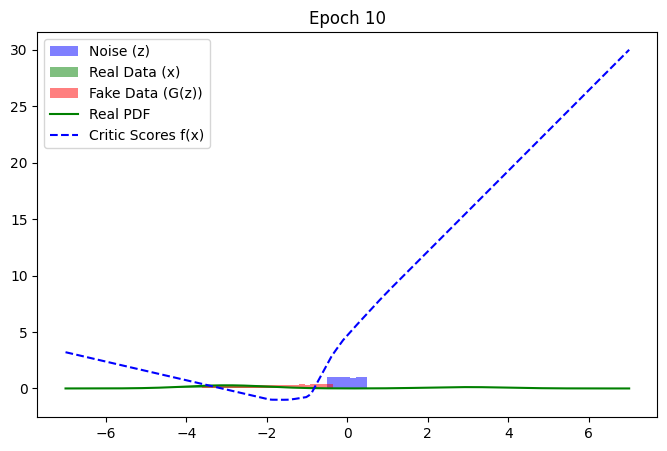

Epoch 11/50: G=-1.631, f_real=6.430, f_fake=1.594, W_Dist=4.836
Epoch 12/50: G=-1.228, f_real=5.475, f_fake=1.250, W_Dist=4.225
Epoch 13/50: G=-1.592, f_real=4.811, f_fake=1.584, W_Dist=3.227
Epoch 14/50: G=-4.743, f_real=7.851, f_fake=4.655, W_Dist=3.196
Epoch 15/50: G=-5.285, f_real=6.651, f_fake=5.266, W_Dist=1.385


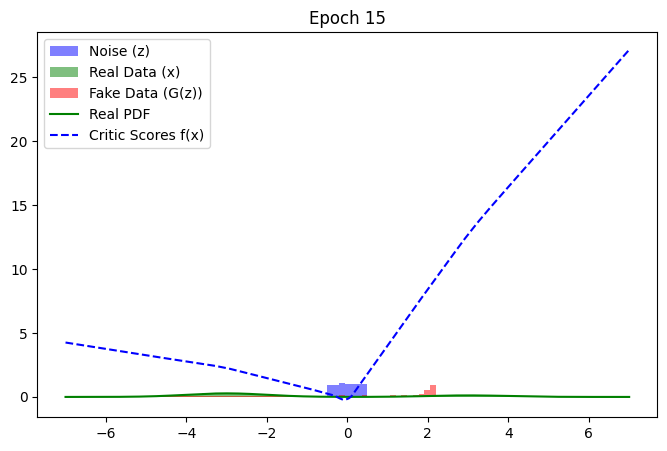

Epoch 16/50: G=-4.022, f_real=4.289, f_fake=3.974, W_Dist=0.315
Epoch 17/50: G=-1.070, f_real=1.124, f_fake=1.114, W_Dist=0.010
Epoch 18/50: G=-0.265, f_real=0.448, f_fake=0.259, W_Dist=0.189
Epoch 19/50: G=-0.343, f_real=0.743, f_fake=0.352, W_Dist=0.392
Epoch 20/50: G=-0.160, f_real=0.702, f_fake=0.125, W_Dist=0.577


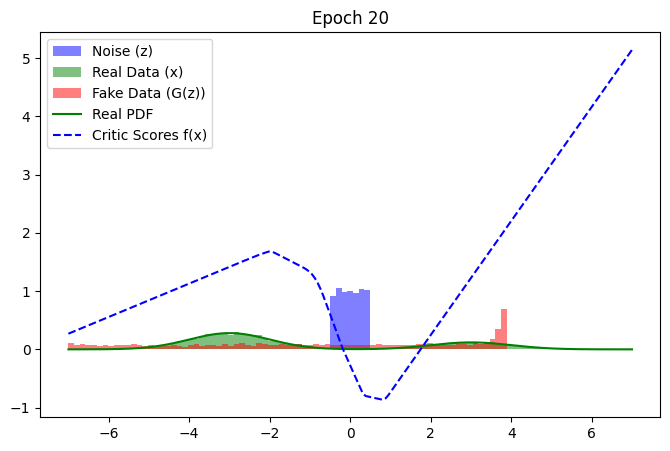

Epoch 21/50: G=-0.094, f_real=0.686, f_fake=0.088, W_Dist=0.599
Epoch 22/50: G=-0.072, f_real=0.728, f_fake=0.056, W_Dist=0.673
Epoch 23/50: G=-0.097, f_real=0.776, f_fake=0.100, W_Dist=0.676
Epoch 24/50: G=0.031, f_real=0.628, f_fake=-0.037, W_Dist=0.665
Epoch 25/50: G=0.102, f_real=0.578, f_fake=-0.100, W_Dist=0.678


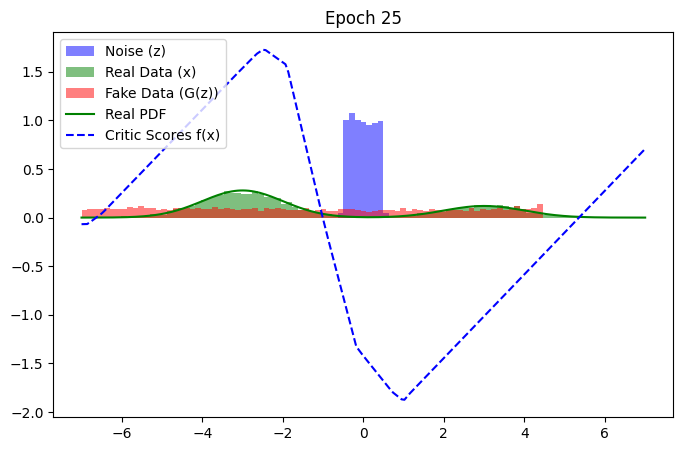

Epoch 26/50: G=-0.036, f_real=0.677, f_fake=0.048, W_Dist=0.630
Epoch 27/50: G=-0.097, f_real=0.671, f_fake=0.080, W_Dist=0.591
Epoch 28/50: G=-0.039, f_real=0.614, f_fake=0.034, W_Dist=0.581
Epoch 29/50: G=-0.068, f_real=0.615, f_fake=0.070, W_Dist=0.545
Epoch 30/50: G=-0.208, f_real=0.695, f_fake=0.163, W_Dist=0.533


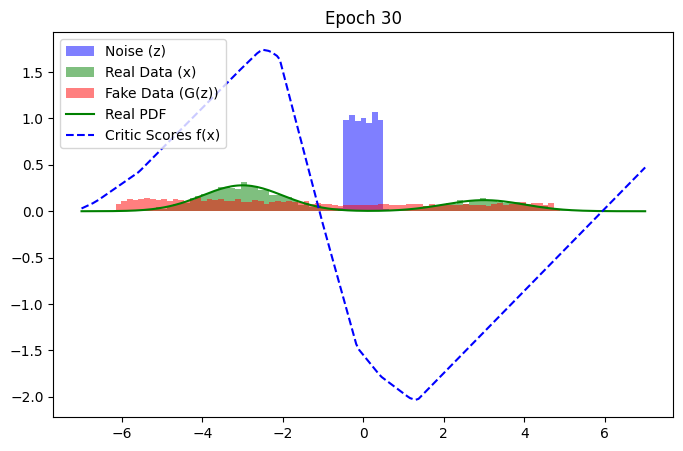

Epoch 31/50: G=-0.120, f_real=0.618, f_fake=0.142, W_Dist=0.476
Epoch 32/50: G=-0.243, f_real=0.690, f_fake=0.241, W_Dist=0.448
Epoch 33/50: G=-0.250, f_real=0.663, f_fake=0.266, W_Dist=0.397
Epoch 34/50: G=-0.531, f_real=0.848, f_fake=0.505, W_Dist=0.343
Epoch 35/50: G=-0.289, f_real=0.622, f_fake=0.308, W_Dist=0.314


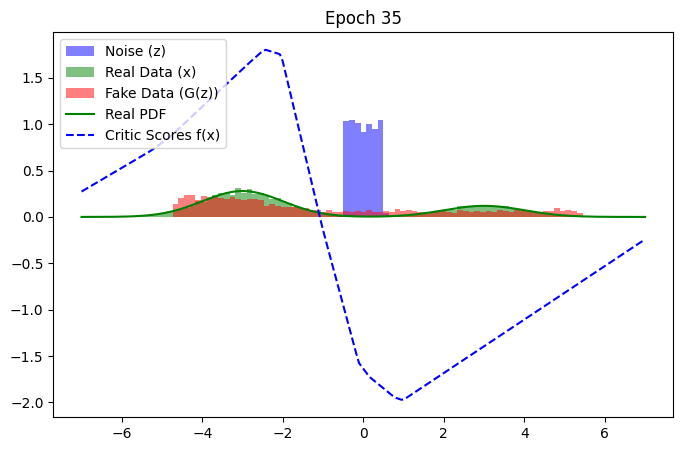

Epoch 36/50: G=-0.656, f_real=0.915, f_fake=0.649, W_Dist=0.266
Epoch 37/50: G=-0.639, f_real=0.822, f_fake=0.615, W_Dist=0.207
Epoch 38/50: G=-0.916, f_real=1.070, f_fake=0.926, W_Dist=0.144
Epoch 39/50: G=-0.709, f_real=0.815, f_fake=0.706, W_Dist=0.109
Epoch 40/50: G=-1.073, f_real=1.127, f_fake=1.035, W_Dist=0.092


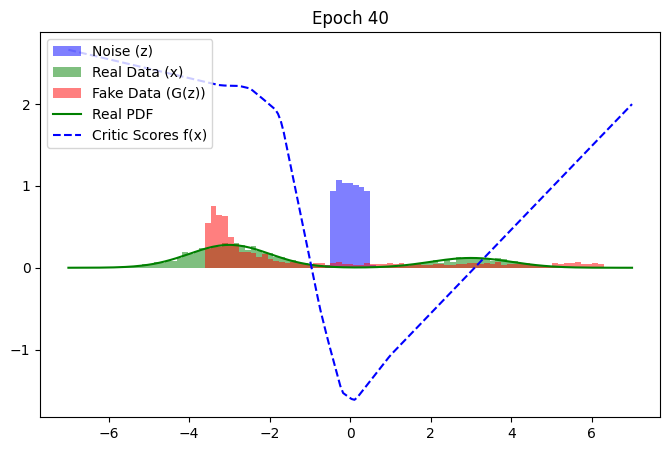

Epoch 41/50: G=-0.940, f_real=0.987, f_fake=0.938, W_Dist=0.049
Epoch 42/50: G=-0.812, f_real=0.850, f_fake=0.817, W_Dist=0.034
Epoch 43/50: G=-1.007, f_real=1.036, f_fake=1.020, W_Dist=0.016
Epoch 44/50: G=-0.451, f_real=0.466, f_fake=0.414, W_Dist=0.052
Epoch 45/50: G=-0.953, f_real=1.009, f_fake=0.958, W_Dist=0.051


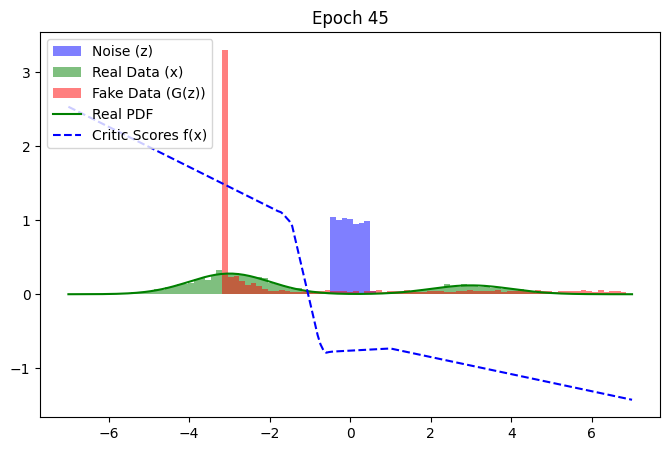

Epoch 46/50: G=-1.148, f_real=1.090, f_fake=1.150, W_Dist=-0.060
Epoch 47/50: G=-0.256, f_real=0.283, f_fake=0.258, W_Dist=0.025
Epoch 48/50: G=0.066, f_real=-0.045, f_fake=-0.060, W_Dist=0.015
Epoch 49/50: G=-0.559, f_real=0.617, f_fake=0.585, W_Dist=0.032
Epoch 50/50: G=-0.760, f_real=0.765, f_fake=0.746, W_Dist=0.019


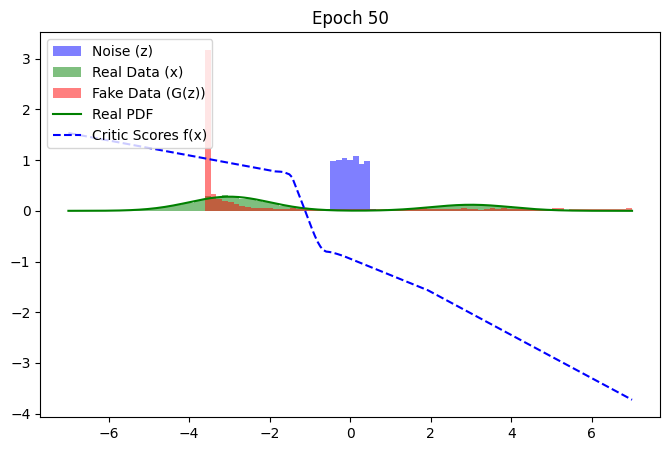

In [157]:
for epoch in range(epochs):
    
    loss_g_running = 0.0
    f_real_running = 0.0
    f_fake_running = 0.0
    
    for i in range(batches_per_epoch):
        
        # Train the Critic n_critic times
        for _ in range(n_critic):
            f_real_step, f_fake_step = wgan.train_step_C()
            f_real_running += f_real_step
            f_fake_running += f_fake_step

        # Train the Generator 1 time
        loss_g_step = wgan.train_step_G()
        loss_g_running += loss_g_step
    
    avg_g_loss = loss_g_running / batches_per_epoch
    avg_f_real = f_real_running / (batches_per_epoch * n_critic)
    avg_f_fake = f_fake_running / (batches_per_epoch * n_critic)
    
    wasserstein_dist = avg_f_real - avg_f_fake
    
    print(f"Epoch {epoch+1}/{epochs}: "
          f"G={avg_g_loss:.3f}, f_real={avg_f_real:.3f}, f_fake={avg_f_fake:.3f}, "
          f"W_Dist={wasserstein_dist:.3f}")

    if (epoch+1) % 5 == 0:
        visualize_GAN(
            sample_z(5000).cpu().numpy(),
            sample_data(5000).cpu().numpy(),
            wgan.generate_samples(num=5000).cpu().numpy(),
            wgan.C,
            data_pdf,
            title=f"Epoch {epoch+1}",
            is_critic=True
        )


- `f_real` и `f_fake` — средние оценки критика на реальных данных и на фейках
- `W_Dist = f_real - f_fake` — оценка расстояния Вассерштейна
- чем лучше генератор, тем меньше `W_Dist`
- оценки критика — это просто числа, а не вероятности, поэтому они не ограничены отрезком $[0, 1]$

Посмотрим на веса критика.

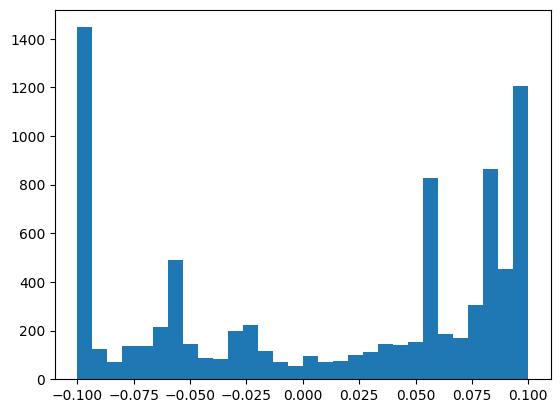

In [158]:
params = []
for param in C.parameters():
    params.extend(param.detach().cpu().numpy().flatten())
plt.hist(params, bins=30)
plt.show()

### WGAN-GP

**`Weight Clipping`** — очень грубый метод ограничения константы Липшица: результат сильно зависит от $c$, а веса прилипают к границам $\pm c$ (это видно на гистограмме выше).

В `WGAN-GP` вместо обрезки весов авторы предложили штрафовать Критика, если норма его градиента **отличается от 1**.

Мы берём старую функцию потерь WGAN и добавляем к ней **Gradient Penalty**:

$$L_{Critic} = \underbrace{\left( \mathbb{E}_{\mathbf{z} \sim p(\mathbf{z})}[f_\phi(G(\mathbf{z}))] - \mathbb{E}_{\mathbf{x} \sim p_{\text{data}}}[f_\phi(\mathbf{x})] \right)}_{\text{ WGAN Loss}} + \underbrace{\lambda_{gp} \cdot \mathbb{E}_{\hat{\mathbf{x}}} \left[ (\|\nabla_{\hat{\mathbf{x}}} f_\phi(\hat{\mathbf{x}})\|_2 - 1)^2 \right]}_{\text{Gradient Penalty}}$$

- $\|\nabla_{\hat{\mathbf{x}}} f_\phi(\hat{\mathbf{x}})\|_2$: $L_2$-норма градиента Критика в случайной точке $\hat{\mathbf{x}}$. Штраф **двусторонний**: наказываем и за слишком крутой, и за слишком пологий критик

- $\lambda_{gp}$: вес штрафа, в статье $\lambda_{gp} = 10$

- $\hat{\mathbf{x}}$: случайная точка на отрезке между реальным и сгенерированным объектом:

$$
\hat{\mathbf{x}} = \epsilon \cdot \mathbf{x} + (1 - \epsilon) \cdot x_{fake}, \qquad \mathbf{x} \sim p_{\text{data}}, \quad \epsilon \sim U[0, 1]
$$

Проверять градиент во всём пространстве мы не можем. Но у оптимального критика $\|\nabla f\| = 1$ как раз на отрезках между реальными и сгенерированными точками, поэтому штрафуем именно там.

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lr = 1e-4           
batch_size = 32
latent_dim = 1
n_critic = 5            
epochs = 50
batches_per_epoch = 100

gen_hiddens = [latent_dim, 64, 64, 64, 1] 
critic_hiddens = [1, 64, 64, 64, 1]          


Критик теперь не обрезается, а штрафуется в методе `compute_gradient_penalty`:

- для каждого примера берём свой $\epsilon \sim U[0, 1]$ и считаем $\hat{\mathbf{x}} = \epsilon \cdot \mathbf{x} + (1 - \epsilon) \cdot G(\mathbf{z})$
- с помощью `autograd.grad` считаем градиент критика по входу $\hat{\mathbf{x}}$
- нужен `create_graph=True`, потому что сам штраф мы потом дифференцируем ещё раз по весам критика
- берём $L_2$-норму градиента каждого примера и считаем штраф $(\|\nabla_{\hat{\mathbf{x}}} f_\phi(\hat{\mathbf{x}})\|_2 - 1)^2$

In [37]:
class WGAN_GP:
    def __init__(self, G, C, sample_z, sample_data, device, n_critic, lambda_gp, lr, batch_size):
        self.G = G.to(device)
        self.C = C.to(device)
        self.sample_z = sample_z
        self.sample_data = sample_data
        self.device = device
        self.batch_size = batch_size
        self.n_critic = n_critic
        self.lambda_gp = lambda_gp
        
        self.optim_C = optim.Adam(C.parameters(), lr=lr, betas=(0.5, 0.9))
        self.optim_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.9))

    def generate_samples(self, z=None, num=None) -> torch.Tensor:
        num = self.batch_size if num is None else num
        z = self.sample_z(num) if z is None else z
        with torch.no_grad():
            samples = self.G(z, y)
        return samples

    def compute_gradient_penalty(self, real_samples, fake_samples):
        epsilon = torch.rand(real_samples.size(0), 1, device=self.device)
        x_hat = (epsilon * real_samples + (1 - epsilon) * fake_samples).requires_grad_(True)
        
        f_x_hat = self.C(x_hat)
        
        grad_outputs = torch.ones_like(f_x_hat, device=self.device)
        
        gradients = autograd.grad(
            outputs=f_x_hat,
            inputs=x_hat,
            grad_outputs=grad_outputs,
            create_graph=True,
            retain_graph=True,
            only_inputs=True,
        )[0]
        
        gradients = gradients.view(gradients.size(0), -1)
        gradient_norm = gradients.norm(2, dim=1)
        
        gradient_penalty = ((gradient_norm - 1) ** 2).mean()
        return gradient_penalty

    def train_step_C(self) -> tuple[float, float, float]:
        self.C.zero_grad()

        real_samples = self.sample_data(self.batch_size)
        real_scores = self.C(real_samples)

        z = self.sample_z(self.batch_size)
        with torch.no_grad():
            fake_samples = self.G(z)
        fake_scores = self.C(fake_samples)

        # The critic maximizes E[f(x)] - E[f(G(z))], so we minimize the opposite
        wgan_loss = (fake_scores.mean()) - (real_scores.mean())
        
        gradient_penalty = self.compute_gradient_penalty(real_samples, fake_samples)
        
        loss_C = wgan_loss + self.lambda_gp * gradient_penalty
        
        loss_C.backward()
        self.optim_C.step()
        
        return real_scores.mean().item(), fake_scores.mean().item(), gradient_penalty.item()

    def train_step_G(self) -> float:
        self.G.zero_grad()
        
        z = self.sample_z(self.batch_size)
        fake_samples = self.G(z)
        fake_scores = self.C(fake_samples)

        loss_G = -fake_scores.mean()
        
        loss_G.backward()
        self.optim_G.step()
        
        return loss_G.item()

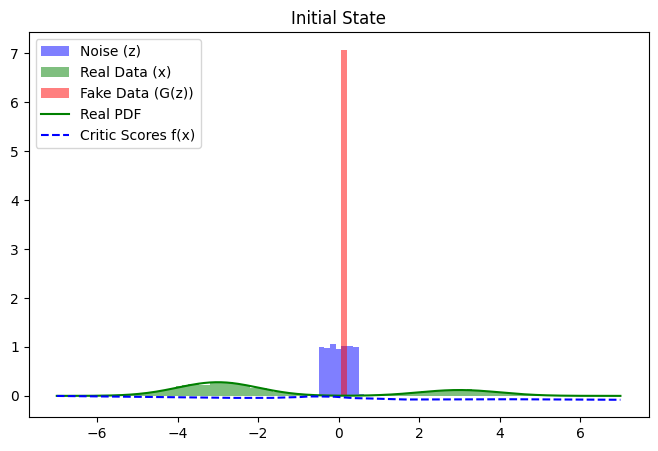

In [164]:
G = Generator(gen_hiddens).to(device)
C = Critic(critic_hiddens).to(device)

visualize_GAN(
    sample_z(5000).cpu().numpy(),
    sample_data(5000).cpu().numpy(),
    G(sample_z(5000)).detach().cpu().numpy(),
    C,
    data_pdf,
    title="Initial State",
    is_critic=True
)

In [165]:
lambda_gp = 1
wgan_gp = WGAN_GP(G, C, sample_z, sample_data, device, n_critic, lambda_gp, lr, batch_size)

Epoch 1/50: G=0.067, f_real=3.272, f_fake=-0.065, W_Dist=3.336, GP=0.754


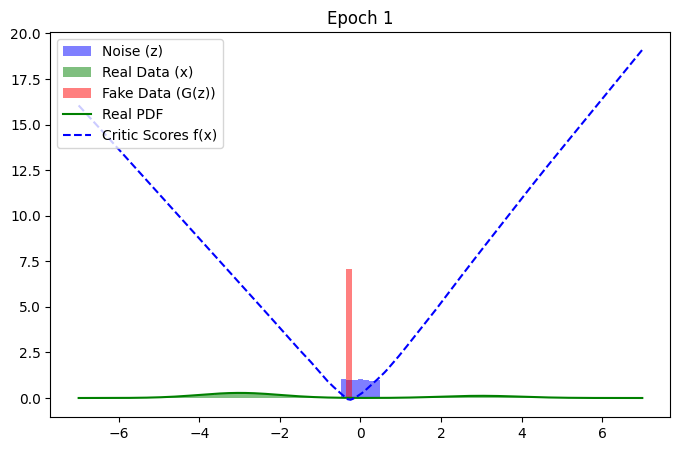

Epoch 2/50: G=0.140, f_real=6.573, f_fake=-0.135, W_Dist=6.708, GP=1.986
Epoch 3/50: G=0.467, f_real=5.638, f_fake=-0.456, W_Dist=6.094, GP=1.813
Epoch 4/50: G=1.780, f_real=4.317, f_fake=-1.776, W_Dist=6.093, GP=1.949
Epoch 5/50: G=1.567, f_real=4.431, f_fake=-1.575, W_Dist=6.005, GP=2.011


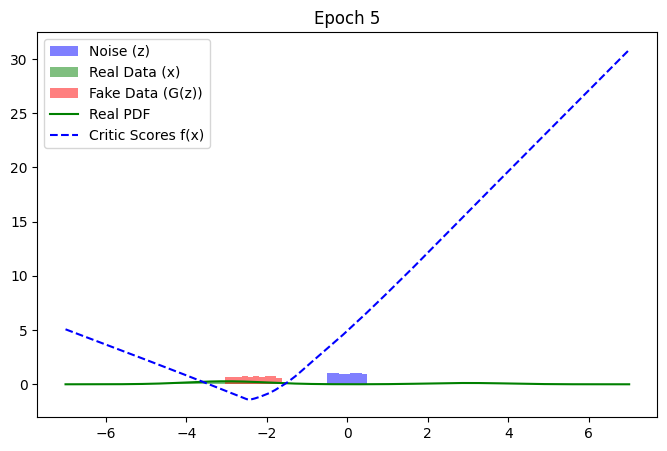

Epoch 6/50: G=0.138, f_real=5.167, f_fake=-0.149, W_Dist=5.317, GP=1.749
Epoch 7/50: G=0.010, f_real=4.785, f_fake=-0.006, W_Dist=4.791, GP=1.649
Epoch 8/50: G=-0.900, f_real=4.529, f_fake=0.908, W_Dist=3.621, GP=1.214
Epoch 9/50: G=-1.470, f_real=3.800, f_fake=1.461, W_Dist=2.339, GP=0.804
Epoch 10/50: G=-1.419, f_real=2.583, f_fake=1.387, W_Dist=1.196, GP=0.515


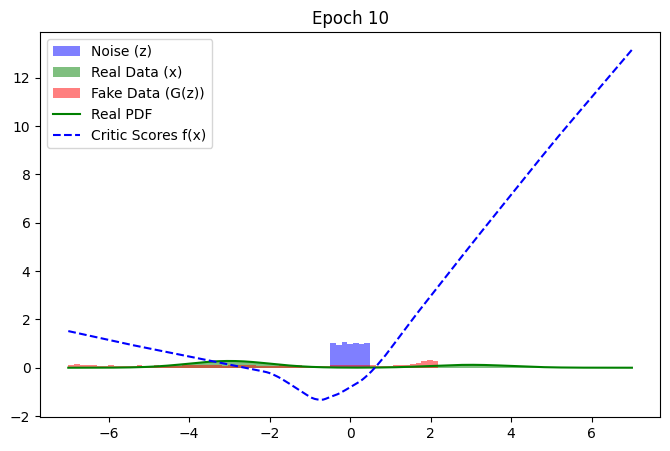

Epoch 11/50: G=-0.290, f_real=0.804, f_fake=0.316, W_Dist=0.489, GP=0.458
Epoch 12/50: G=3.675, f_real=-2.748, f_fake=-3.689, W_Dist=0.941, GP=0.303
Epoch 13/50: G=4.437, f_real=-3.130, f_fake=-4.396, W_Dist=1.266, GP=0.420
Epoch 14/50: G=4.466, f_real=-3.332, f_fake=-4.453, W_Dist=1.121, GP=0.343
Epoch 15/50: G=4.140, f_real=-3.079, f_fake=-4.106, W_Dist=1.027, GP=0.275


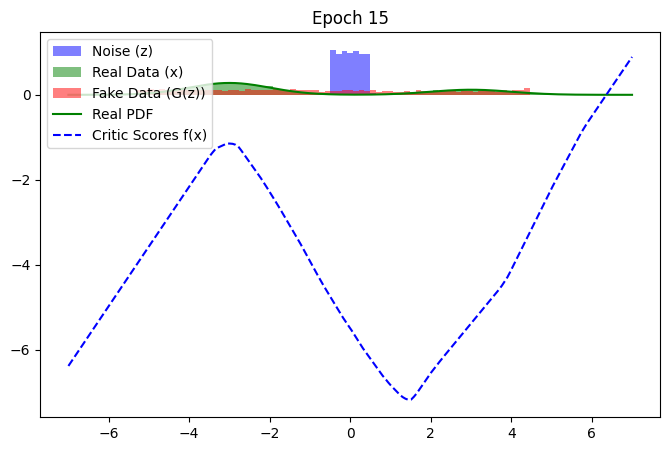

Epoch 16/50: G=3.801, f_real=-2.895, f_fake=-3.830, W_Dist=0.935, GP=0.213
Epoch 17/50: G=3.769, f_real=-2.947, f_fake=-3.840, W_Dist=0.893, GP=0.179
Epoch 18/50: G=3.831, f_real=-2.997, f_fake=-3.852, W_Dist=0.855, GP=0.158
Epoch 19/50: G=3.811, f_real=-2.985, f_fake=-3.768, W_Dist=0.783, GP=0.134
Epoch 20/50: G=3.502, f_real=-2.859, f_fake=-3.551, W_Dist=0.692, GP=0.113


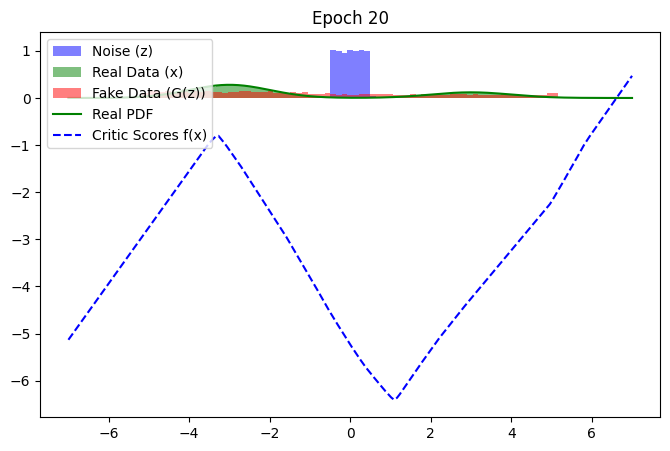

Epoch 21/50: G=3.437, f_real=-2.778, f_fake=-3.426, W_Dist=0.648, GP=0.102
Epoch 22/50: G=3.338, f_real=-2.758, f_fake=-3.318, W_Dist=0.560, GP=0.087
Epoch 23/50: G=3.207, f_real=-2.736, f_fake=-3.242, W_Dist=0.507, GP=0.081
Epoch 24/50: G=3.107, f_real=-2.664, f_fake=-3.095, W_Dist=0.431, GP=0.073
Epoch 25/50: G=3.153, f_real=-2.782, f_fake=-3.152, W_Dist=0.370, GP=0.072


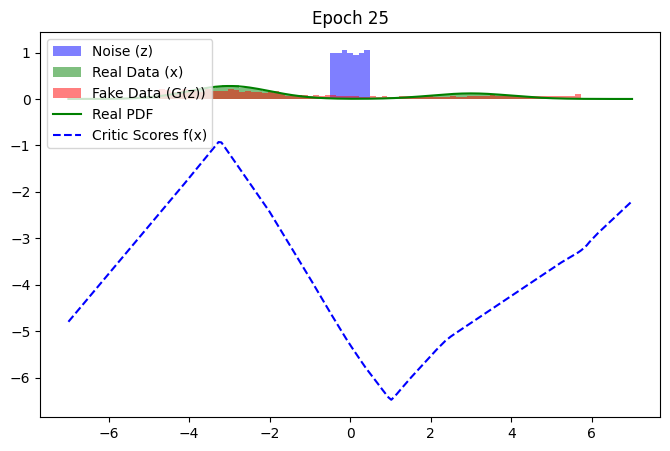

Epoch 26/50: G=3.035, f_real=-2.715, f_fake=-3.027, W_Dist=0.312, GP=0.065
Epoch 27/50: G=2.808, f_real=-2.582, f_fake=-2.804, W_Dist=0.222, GP=0.059
Epoch 28/50: G=2.812, f_real=-2.601, f_fake=-2.786, W_Dist=0.185, GP=0.066
Epoch 29/50: G=2.748, f_real=-2.624, f_fake=-2.763, W_Dist=0.139, GP=0.080
Epoch 30/50: G=3.062, f_real=-3.016, f_fake=-3.059, W_Dist=0.043, GP=0.085


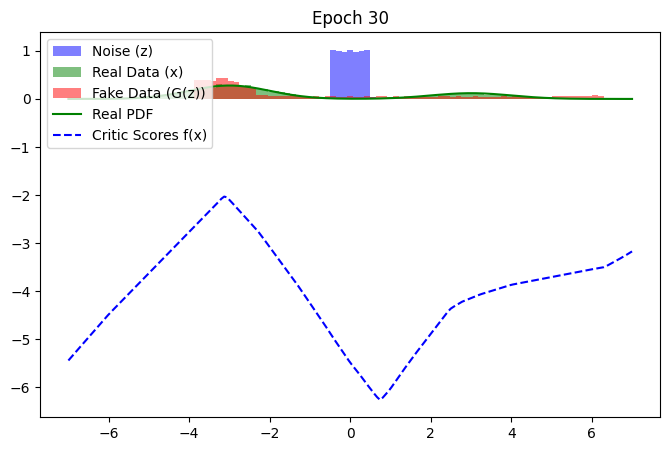

Epoch 31/50: G=2.935, f_real=-2.976, f_fake=-2.963, W_Dist=-0.013, GP=0.106
Epoch 32/50: G=2.944, f_real=-2.985, f_fake=-2.952, W_Dist=-0.033, GP=0.162
Epoch 33/50: G=4.449, f_real=-4.456, f_fake=-4.435, W_Dist=-0.021, GP=0.219
Epoch 34/50: G=1.284, f_real=-1.195, f_fake=-1.315, W_Dist=0.120, GP=0.331
Epoch 35/50: G=2.543, f_real=-2.258, f_fake=-2.481, W_Dist=0.223, GP=0.290


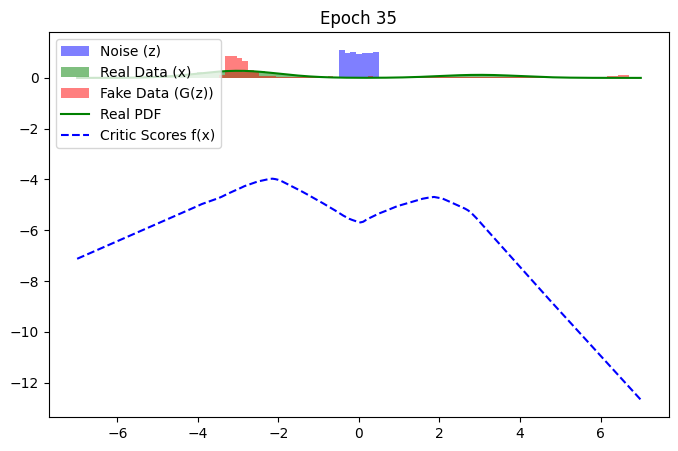

Epoch 36/50: G=4.292, f_real=-4.066, f_fake=-4.329, W_Dist=0.263, GP=0.263
Epoch 37/50: G=1.830, f_real=-1.439, f_fake=-1.802, W_Dist=0.362, GP=0.337
Epoch 38/50: G=2.139, f_real=-1.657, f_fake=-2.110, W_Dist=0.453, GP=0.336
Epoch 39/50: G=2.021, f_real=-1.409, f_fake=-2.046, W_Dist=0.637, GP=0.311
Epoch 40/50: G=1.706, f_real=-1.096, f_fake=-1.710, W_Dist=0.614, GP=0.308


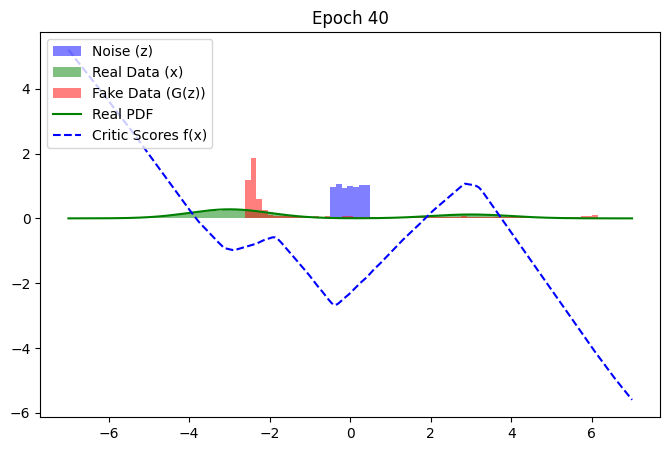

Epoch 41/50: G=0.428, f_real=0.626, f_fake=-0.425, W_Dist=1.051, GP=0.395
Epoch 42/50: G=0.440, f_real=0.686, f_fake=-0.465, W_Dist=1.151, GP=0.441
Epoch 43/50: G=1.808, f_real=-1.300, f_fake=-1.680, W_Dist=0.380, GP=0.381
Epoch 44/50: G=3.526, f_real=-2.978, f_fake=-3.537, W_Dist=0.560, GP=0.330
Epoch 45/50: G=2.848, f_real=-2.184, f_fake=-2.836, W_Dist=0.652, GP=0.327


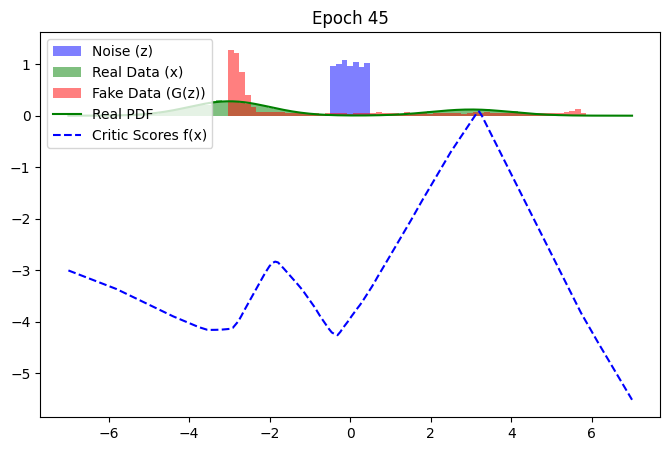

Epoch 46/50: G=0.611, f_real=0.449, f_fake=-0.624, W_Dist=1.073, GP=0.343
Epoch 47/50: G=0.872, f_real=-0.010, f_fake=-0.830, W_Dist=0.821, GP=0.397
Epoch 48/50: G=3.008, f_real=-2.596, f_fake=-3.003, W_Dist=0.407, GP=0.352
Epoch 49/50: G=3.850, f_real=-3.451, f_fake=-3.754, W_Dist=0.303, GP=0.353
Epoch 50/50: G=5.363, f_real=-5.057, f_fake=-5.406, W_Dist=0.348, GP=0.343


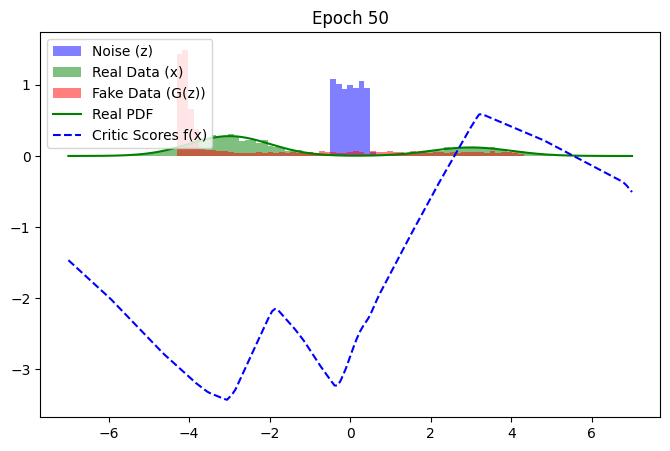

In [166]:
for epoch in range(epochs):
    
    loss_g_running = 0.0
    f_real_running = 0.0
    f_fake_running = 0.0
    gp_running = 0.0
    
    for i in range(batches_per_epoch):
        
        for _ in range(n_critic):
            f_real_step, f_fake_step, gp_step = wgan_gp.train_step_C()
            f_real_running += f_real_step
            f_fake_running += f_fake_step
            gp_running += gp_step

        loss_g_step = wgan_gp.train_step_G()
        loss_g_running += loss_g_step
    
    avg_g_loss = loss_g_running / batches_per_epoch
    avg_f_real = f_real_running / (batches_per_epoch * n_critic)
    avg_f_fake = f_fake_running / (batches_per_epoch * n_critic)
    avg_gp = gp_running / (batches_per_epoch * n_critic)
    
    wasserstein_dist = avg_f_real - avg_f_fake
    
    print(f"Epoch {epoch+1}/{epochs}: "
          f"G={avg_g_loss:.3f}, f_real={avg_f_real:.3f}, f_fake={avg_f_fake:.3f}, "
          f"W_Dist={wasserstein_dist:.3f}, GP={avg_gp:.3f}")

    if epoch == 0 or (epoch+1) % 5 == 0:
        visualize_GAN(
            sample_z(5000).cpu().numpy(),
            sample_data(5000).cpu().numpy(),
            wgan_gp.generate_samples(num=5000).cpu().numpy(),
            wgan_gp.C,
            data_pdf,
            title=f"Epoch {epoch+1}",
            is_critic=True
        )


Снова посмотрим на веса критика.

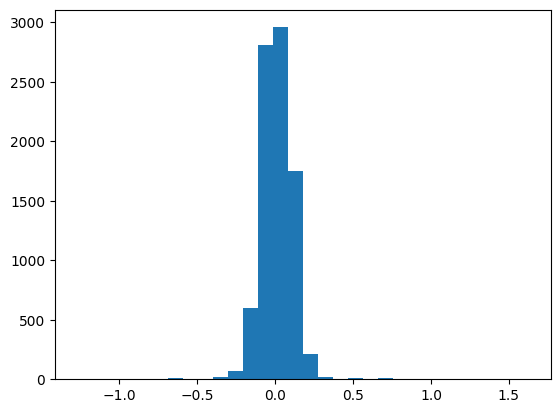

In [167]:
params = []
for param in C.parameters():
    params.extend(param.detach().cpu().numpy().flatten())
plt.hist(params, bins=30)
plt.show()

### WGAN-GP on MNIST

Применим WGAN-GP к MNIST:

- картинки $28 \times 28$ разворачиваем в вектор из $784$ чисел, сети остаются MLP
- пиксели нормализуем в $[-1, 1]$, поэтому на выходе генератора стоит `Tanh`

In [180]:
n_epochs = 50
batch_size = 128
lr = 5e-4
beta1 = 0.5            
beta2 = 0.9            
latent_dim = 128 
img_size = 28
channels = 1
n_critic = 5        
lambda_gp = 10     

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_shape = (channels, img_size, img_size)
img_flat_dim = int(np.prod(img_shape))

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [181]:
class MnistGenerator(nn.Module):
    def __init__(self, hiddens, img_shape):
        super().__init__()
        self.img_shape = img_shape
        layers = []
        for i, (in_dim, out_dim) in enumerate(zip(hiddens[:-1], hiddens[1:])):
            layers.append(nn.Linear(in_dim, out_dim))
            if i < len(hiddens) - 2:
                layers.append(nn.BatchNorm1d(out_dim))
                layers.append(nn.LeakyReLU(0.2, inplace=True))
        
        layers.append(nn.Tanh())
        self.model = nn.Sequential(*layers)

    def forward(self, z):
        img_flat = self.model(z)
        return img_flat.view(img_flat.size(0), *self.img_shape)

class MnistCritic(nn.Module):
    def __init__(self, hiddens):
        super().__init__()
        layers = []
        for i, (in_dim, out_dim) in enumerate(zip(hiddens[:-1], hiddens[1:])):
            layers.append(nn.Linear(in_dim, out_dim))
            if i < len(hiddens) - 2:
                layers.append(nn.LeakyReLU(0.2, inplace=True))
        
        self.model = nn.Sequential(*layers)

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        score = self.model(img_flat)
        return score

In [182]:
class WGAN_GP_MNIST:
    def __init__(self, G, C, device, n_critic, lambda_gp, lr, beta1, beta2):
        self.G = G.to(device)
        self.C = C.to(device)
        self.device = device
        self.n_critic = n_critic
        self.lambda_gp = lambda_gp
        
        self.optim_C = optim.Adam(C.parameters(), lr=lr, betas=(beta1, beta2))
        self.optim_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))

    def generate_samples(self, z) -> torch.Tensor:
        with torch.no_grad():
            samples = self.G(z)
        return samples

    def compute_gradient_penalty(self, real_samples, fake_samples, current_batch_size):        
        epsilon = torch.rand(current_batch_size, 1, 1, 1, device=self.device)
        x_hat = (epsilon * real_samples + (1 - epsilon) * fake_samples).requires_grad_(True)
        
        f_x_hat = self.C(x_hat)
        
        grad_outputs = torch.ones(current_batch_size, 1, device=self.device)
        
        gradients = autograd.grad(
            outputs=f_x_hat,
            inputs=x_hat,
            grad_outputs=grad_outputs,
            create_graph=True,
            retain_graph=True,
        )[0]
        
        gradients = gradients.view(gradients.size(0), -1)
        gradient_norm = gradients.norm(2, dim=1)
        
        gradient_penalty = ((gradient_norm - 1) ** 2).mean()
        return gradient_penalty

    def train_step_C(self, real_samples, z, current_batch_size) -> tuple[float, float, float]:
        self.C.zero_grad()

        real_scores = self.C(real_samples)

        with torch.no_grad():
            fake_samples = self.G(z)
        fake_scores = self.C(fake_samples)

        # The critic maximizes E[f(x)] - E[f(G(z))], so we minimize the opposite
        wgan_loss = (fake_scores.mean()) - (real_scores.mean())
        
        gradient_penalty = self.compute_gradient_penalty(real_samples, fake_samples, current_batch_size)
        
        loss_C = wgan_loss + self.lambda_gp * gradient_penalty
        
        loss_C.backward()
        self.optim_C.step()
        
        return real_scores.mean().item(), fake_scores.mean().item(), gradient_penalty.item()

    def train_step_G(self, z) -> float:
        self.G.zero_grad()
        
        fake_samples = self.G(z)
        fake_scores = self.C(fake_samples)

        # Loss: min [-E[f(G(z))]]
        loss_G = -fake_scores.mean()
        
        loss_G.backward()
        self.optim_G.step()
        
        return loss_G.item()

In [183]:
def show_generated_images(gan, num_images=10, title=""):
    gan.G.eval()
    
    z = torch.randn(num_images, latent_dim, device=device)
    gen_imgs = gan.generate_samples(z)
    
    gen_imgs = (gen_imgs * 0.5 + 0.5).clamp(0, 1)
    
    grid = make_grid(gen_imgs, nrow=num_images)
    
    plt.figure(figsize=(10, 2))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(title)
    plt.axis('off')
    plt.show()

    gan.G.train()

def plot_losses(g_losses, w_dists, gp_losses):
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(g_losses)
    plt.title('Generator Loss')
    plt.xlabel('Epoch')
    plt.grid(True)
    
    plt.subplot(1, 3, 2)
    plt.plot(w_dists)
    plt.title('Wasserstein Distance')
    plt.xlabel('Epoch')
    plt.grid(True)
    
    plt.subplot(1, 3, 3)
    plt.plot(gp_losses)
    plt.title('Gradient Penalty')
    plt.xlabel('Epoch')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

In [184]:
gen_hiddens = [latent_dim, 128, 256, 512, 1024, img_flat_dim]
critic_hiddens = [img_flat_dim, 512, 256, 1]

G = MnistGenerator(gen_hiddens, img_shape).to(device)
C = MnistCritic(critic_hiddens).to(device)
wgan_gp = WGAN_GP_MNIST(G, C, device, n_critic, lambda_gp, lr, beta1, beta2)

g_losses_epoch = []
w_dists_epoch = []
gp_losses_epoch = []

#### Цикл обучения

- на каждом шаге критика берём **новый** батч реальных данных
- после $n_{critic}$ шагов критика делаем один шаг генератора
- одна эпоха — один проход по всем реальным картинкам

- `Wasserstein Distance` должна падать
- `Gradient Penalty` должен быть небольшим и ровным - это значит критик почти $1$-Липшицев

Epoch 50/50
G loss: -2.6407, W-Dist: 0.6917, GP: 0.0100


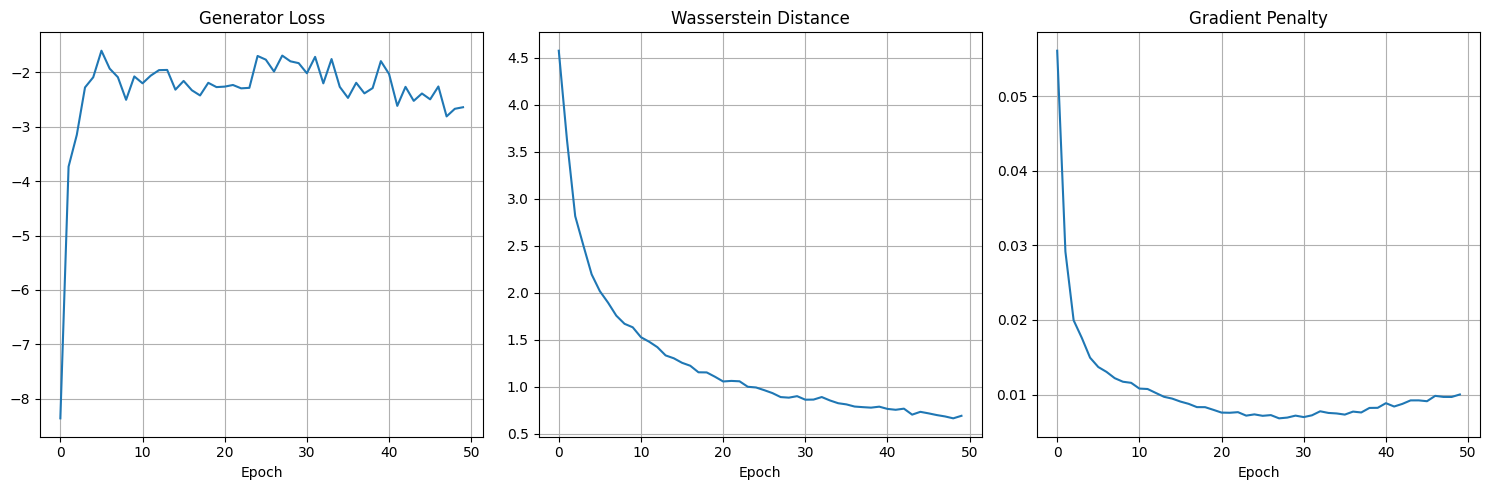

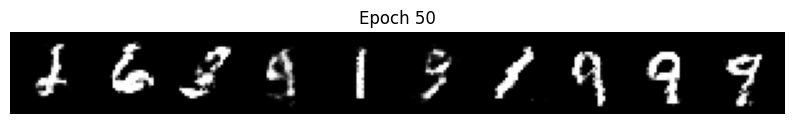

In [185]:
data_iter = iter(train_loader)

def next_real_batch():
    global data_iter
    try:
        imgs, _ = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        imgs, _ = next(data_iter)
    return imgs.to(device)

# one epoch is one pass over all real images, G is updated once per n_critic batches
steps_per_epoch = len(train_loader) // n_critic

for epoch in range(n_epochs):
    
    epoch_g_loss = []
    epoch_w_dist = []
    epoch_gp_loss = []
    
    for step in range(steps_per_epoch):

        wgan_gp.G.train()
        wgan_gp.C.train()
        
        f_real_avg = 0.0
        f_fake_avg = 0.0
        gp_avg = 0.0

        # each critic step uses a fresh batch of real data
        for _ in range(n_critic):
            real_imgs = next_real_batch()
            current_batch_size = real_imgs.size(0)
            z = torch.randn(current_batch_size, latent_dim, device=device)
            f_real_step, f_fake_step, gp_step = wgan_gp.train_step_C(real_imgs, z, current_batch_size)
            f_real_avg += f_real_step
            f_fake_avg += f_fake_step
            gp_avg += gp_step

        z = torch.randn(batch_size, latent_dim, device=device)
        loss_G = wgan_gp.train_step_G(z)
        
        f_real_avg /= n_critic
        f_fake_avg /= n_critic
        gp_avg /= n_critic
        w_dist = f_real_avg - f_fake_avg
        
        epoch_g_loss.append(loss_G)
        epoch_w_dist.append(w_dist)
        epoch_gp_loss.append(gp_avg)
    
    clear_output(wait=True)
    
    avg_g = np.mean(epoch_g_loss)
    avg_w = np.mean(epoch_w_dist)
    avg_gp = np.mean(epoch_gp_loss)
    
    g_losses_epoch.append(avg_g)
    w_dists_epoch.append(avg_w)
    gp_losses_epoch.append(avg_gp)

    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"G loss: {avg_g:.4f}, W-Dist: {avg_w:.4f}, GP: {avg_gp:.4f}")
    
    plot_losses(g_losses_epoch, w_dists_epoch, gp_losses_epoch)
    show_generated_images(wgan_gp, num_images=10, title=f"Epoch {epoch+1}")

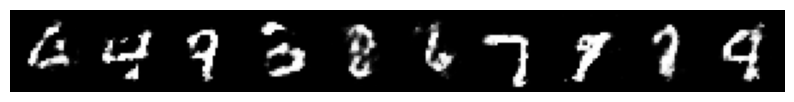

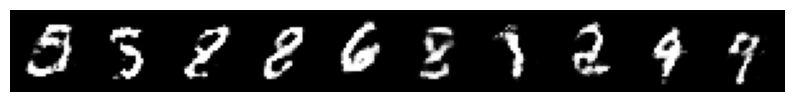

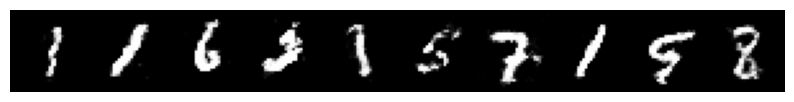

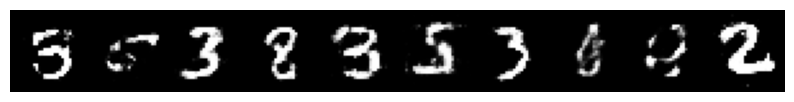

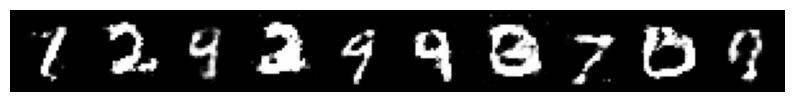

In [186]:
for i in range(5):
    show_generated_images(wgan_gp, num_images=10)

### Сравнение подходов

| | GAN | WGAN | WGAN-GP |
|---|---|---|---|
| **Что минимизируем** | JSD | расстояние Вассерштейна | расстояние Вассерштейна |
| **Выход второй сети** | вероятность | оценка | оценка |
| **Ограничение на сеть** | нет | обрезка весов | штраф за норму градиента |
| **Основные проблемы** | исчезающие градиенты, потеря мод | грубое ограничение, зависит от $c$ | подбор $\lambda_{gp}$, дороже по вычислениям |